In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np
from dataclasses import dataclass
from typing import Literal

In [2]:
HOURLY_RATE = 12.71
# TOTAL_ANNOTATIONS = 1000
NUM_ANNOTATIONS_PER_HUMAN = 5
NUM_ANNOTATIONS_PER_SAMPLE = 30
DIALOGUE_TURN_ANNOTATION_CHUNK_SIZE = 2 # So a chunk size of 2 would include one dialogue move from both speakers, chunk size = 4 would contain two dialogue moves from both speakers, and so on.
MINS_PER_ANNOTATION = 2 * DIALOGUE_TURN_ANNOTATION_CHUNK_SIZE
PLATFORM_FEE = 0.33
VAT = 0.2
PROLIFIC_BUDGET=9634.20

In [3]:
def compute_cost(
    full_pairs_df,
    hourly_rate: float = 12.71,
    num_annotations_per_human: int = 5,
    num_annotations_per_sample: int = 30,
    dialogue_turn_chunk_size: int = 2,
    mins_per_chunk: float = 2.0,
    platform_fee: float = 0.33,
    vat: float = 0.2,
    prolific_budget: float = 9634.20
):
    """
    Compute the cost of annotation for a given pairs DataFrame.
    
    Args:
        full_pairs_df: DataFrame containing comparison pairs
        hourly_rate: Hourly rate for annotators (£)
        num_annotations_per_human: Number of annotations each human does
        num_annotations_per_sample: Number of annotations needed per sample
        dialogue_turn_chunk_size: Size of dialogue chunks
        mins_per_chunk: Minutes per chunk to annotate
        platform_fee: Prolific platform fee (as decimal, e.g., 0.33 for 33%)
        vat: VAT rate (as decimal, e.g., 0.2 for 20%)
        prolific_budget: Total available budget (£)
    
    Returns:
        Dictionary with cost breakdown
    """
    # Use mins_per_chunk directly instead of calculating from chunk size
    mins_per_annotation = dialogue_turn_chunk_size * mins_per_chunk
    
    # Number of comparisons in the dataframe
    num_comparisons = len(full_pairs_df)
    print(f"Number of comparisons in df: {num_comparisons}")

    # Total annotations needed (each comparison annotated by multiple humans)
    total_annotations_needed = num_comparisons * num_annotations_per_sample
    print(f"Total annotations needed (with {num_annotations_per_sample} annotations per sample): {total_annotations_needed}")

    # Number of unique human annotators needed
    num_annotators = total_annotations_needed / num_annotations_per_human
    print(f"Number of unique annotators needed (each does {num_annotations_per_human} annotations): {num_annotators:.0f}")

    # Time per annotation in minutes
    print(f"Minutes per annotation (dialogue turns {dialogue_turn_chunk_size}): {mins_per_annotation}")

    # Total time in minutes and hours
    total_mins = total_annotations_needed * mins_per_annotation
    total_hours = total_mins / 60
    print(f"Total annotation time: {total_mins} mins ({total_hours:.2f} hours)")

    # Time per annotator
    mins_per_annotator = num_annotations_per_human * mins_per_annotation
    print(f"Time per annotator: {mins_per_annotator} mins ({mins_per_annotator/60:.2f} hours)")

    # Base cost (payment to annotators)
    base_cost = total_hours * hourly_rate
    print(f"Base cost (annotator payment): £{base_cost:.2f}")

    # Platform fee (Prolific charges 33% on top)
    platform_fee_amount = base_cost * platform_fee
    print(f"Platform fee ({platform_fee*100:.0f}%): £{platform_fee_amount:.2f}")

    # Subtotal before VAT
    subtotal = base_cost + platform_fee_amount
    print(f"Subtotal (before VAT): £{subtotal:.2f}")

    # VAT on platform fee only (Prolific charges VAT on their fee)
    vat_amount = platform_fee_amount * vat
    print(f"VAT on platform fee ({vat*100:.0f}%): £{vat_amount:.2f}")

    # Total cost
    total_cost = base_cost + platform_fee_amount + vat_amount
    print(f"\n{'='*40}")
    print(f"TOTAL COST: £{total_cost:.2f}")
    print(f"{'='*40}")

    # Check against budget
    print(f"\nProlific Budget: £{prolific_budget:.2f}")
    print(f"Remaining budget: £{prolific_budget - total_cost:.2f}")
    print(f"Within budget: {total_cost <= prolific_budget}")

    # Cost per comparison
    cost_per_comparison = total_cost / num_comparisons if num_comparisons > 0 else 0
    print(f"\nCost per comparison: £{cost_per_comparison:.2f}")

    # How many comparisons can we afford with the budget?
    max_comparisons = int(prolific_budget / cost_per_comparison) if cost_per_comparison > 0 else 0
    print(f"Max comparisons with budget: {max_comparisons}")

    return {
        "num_comparisons": num_comparisons,
        "total_annotations": total_annotations_needed,
        "num_annotators": num_annotators,
        "total_hours": total_hours,
        "base_cost": base_cost,
        "platform_fee": platform_fee_amount,
        "vat": vat_amount,
        "total_cost": total_cost,
        "within_budget": total_cost <= prolific_budget,
        "cost_per_comparison": cost_per_comparison,
        "max_comparisons": max_comparisons
    }

In [4]:
SEED = 123
np.random.seed(SEED)

In [5]:
@dataclass
class DebateData:
    session_id : str
    speaker_name:str
    opponent_name:str
    dialogue_history:list
    total_length_dialogue: int
    num_dialogue_moves_for_this_speaker:int
    speaker_order : Literal["first", "second"]
    political_position: Literal["left", "right"]

# ALL DEBATES (i.e. M2M, H2M, H2H)

In [6]:
all_debates_path = Path() / "data" / "all-debates.csv"
all_df = pd.read_csv(all_debates_path, sep="|", encoding="utf-8'")
len(all_df)

192

In [7]:
all_df.head()

,Unnamed: 0,loser,winner,session_id,debate_topic,next_speaker,first_speaker,second_speaker,current_speaker,dialogue_history,...,max_sentences,speaker_order,original_claim,opponents_utterance,opponent_speaker_name,opponents_commitments,opponents_original_claim,utterance_with_corresponding_types,typical_replies_for_last_speakers_response,opponents_utterance_with_corresponding_types
0,0,NaN,NaN,gpt-4o_base:l__vs__grok-3_base:r,Debate the trade-offs of government interventi...,second_speaker,gpt-4o_base,grok-3_base,first_speaker,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,NaN,gpt-4o_base:l__vs__mistral-medium_base:r,Debate the trade-offs of government interventi...,second_speaker,gpt-4o_base,mistral-medium_base,first_speaker,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,grok-3_base,gpt-4o_base,gpt-4o_base:r__vs__grok-3_base:l,Debate the trade-offs of government interventi...,second_speaker,gpt-4o_base,grok-3_base,first_speaker,"[{'speaker': 'gpt-4o_base', 'sentences_with_ut...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,gpt-4o_base:r__vs__mistral-medium_base:l,Debate the trade-offs of government interventi...,second_speaker,gpt-4o_base,mistral-medium_base,first_speaker,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,NaN,NaN,grok-3_base:l__vs__gpt-4o_base:r,Debate the trade-offs of government interventi...,second_speaker,grok-3_base,gpt-4o_base,first_speaker,"[{'speaker': 'grok-3_base', 'timestamp': '2025...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
session_ids = all_df["session_id"].to_list()
length_dialogues = [len(ast.literal_eval(x)) for x in all_df["dialogue_history"].tolist()]

In [9]:
print(length_dialogues)

[40, 40, 4, 40, 40, 7, 40, 40, 40, 8, 40, 10, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 2, 2, 40, 40, 40, 40, 40, 2, 40, 40, 40, 40, 2, 2, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 2, 40, 40, 40, 40, 2, 2, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 18, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 2, 40, 40, 40, 40, 40, 40, 40, 40, 2, 40, 2, 2, 2, 2, 2, 8, 2, 2, 2, 2, 12, 10, 7, 18, 25, 4, 5, 10, 8, 8, 15, 13, 7, 1, 8, 8, 8, 5, 24, 11, 6, 8, 13, 18, 8, 13, 17, 6, 13, 18, 13, 10, 2, 6, 5, 3, 8, 7, 19, 6, 5, 11, 4, 11, 10, 2, 7, 14]


Text(0.5, 0, 'Session IDs')

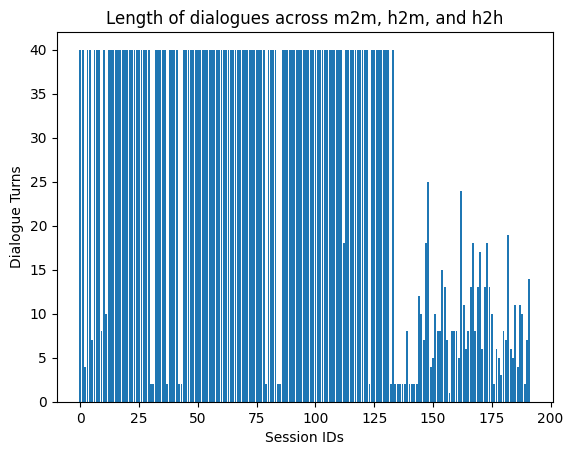

In [10]:
plt.bar(np.arange(0, len(length_dialogues)), length_dialogues)
plt.title("Length of dialogues across m2m, h2m, and h2h")
plt.ylabel("Dialogue Turns")
plt.xlabel("Session IDs")

## Compute possible pairings
Constraints:
- We only want to compare dialogues with the same political position
- We want to consider chunks of the dialogues. However, this is difficult because all dialogue lengths are different. To account for this we will find pairs of dialogues first, and then consider chunks of dialogues.
- We need to make a decision about whether to consider humans as individuals or aggregate them together to produce a ranking using 1 human as a parameter

## Considering individual humans

In [11]:
all_df["first_speaker_political_position_range"]

0      20:40
1      20:40
2      60:80
3      60:80
4      20:40
       ...  
187    60:80
188    20:40
189    20:40
190    20:40
191    20:40
Name: first_speaker_political_position_range, Length: 192, dtype: str

In [12]:
speakers = ["first_speaker", "second_speaker"]

speaker_data_for_all_debates = []
for index, row in all_df.iterrows():
    for speaker in speakers:
        dialogue_hist = ast.literal_eval(row["dialogue_history"])


        d = DebateData(
            session_id=row["session_id"],
            dialogue_history=dialogue_hist,
            total_length_dialogue=len(dialogue_hist),
            num_dialogue_moves_for_this_speaker=int(len(dialogue_hist)/2) if len(dialogue_hist) % 2 == 0 else int(len(dialogue_hist)//2+1),
            speaker_order="first" if speaker == "first_speaker" else "second",
            speaker_name=row[speaker],
            opponent_name=row["first_speaker"] if "second_speaker" == speaker else row["second_speaker"],
            political_position="left" if row[f"{speaker}_political_position_range"] == "20:40" else "right"
        )

        speaker_data_for_all_debates.append(d)
assert len(all_df) * 2 == len(speaker_data_for_all_debates)

In [13]:
df = pd.DataFrame(speaker_data_for_all_debates)

In [14]:
df.tail(20)

,session_id,speaker_name,opponent_name,dialogue_history,total_length_dialogue,num_dialogue_moves_for_this_speaker,speaker_order,political_position
364,F5ZY8K,human_4,grok-3_base,"[{'speaker': 'human_4', 'timestamp': '2026-01-...",19,10,first,right
365,F5ZY8K,grok-3_base,human_4,"[{'speaker': 'human_4', 'timestamp': '2026-01-...",19,10,second,left
366,KONKBD,human_10,human_7,"[{'speaker': 'human_10', 'timestamp': '2026-01...",6,3,first,left
367,KONKBD,human_7,human_10,"[{'speaker': 'human_10', 'timestamp': '2026-01...",6,3,second,right
368,NFQKN3,human_1,human_5,"[{'speaker': 'human_1', 'timestamp': '2026-01-...",5,3,first,right
369,NFQKN3,human_5,human_1,"[{'speaker': 'human_1', 'timestamp': '2026-01-...",5,3,second,left
370,38VH8Y,human_3,gpt-4o_mas,"[{'speaker': 'human_3', 'timestamp': '2026-01-...",11,6,first,right
371,38VH8Y,gpt-4o_mas,human_3,"[{'speaker': 'human_3', 'timestamp': '2026-01-...",11,6,second,left
372,XV0VNG,human_5,human_3,"[{'speaker': 'human_5', 'timestamp': '2026-01-...",4,2,first,left
373,XV0VNG,human_3,human_5,"[{'speaker': 'human_5', 'timestamp': '2026-01-...",4,2,second,right


In [15]:
right_df = df[df["political_position"] == "right"]
left_df = df[df["political_position"] == "left"]
right_session_ids = right_df["session_id"].tolist()
left_session_ids = left_df["session_id"].tolist()

In [16]:
left_df.head()

,session_id,speaker_name,opponent_name,dialogue_history,total_length_dialogue,num_dialogue_moves_for_this_speaker,speaker_order,political_position
0,gpt-4o_base:l__vs__grok-3_base:r,gpt-4o_base,grok-3_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",40,20,first,left
2,gpt-4o_base:l__vs__mistral-medium_base:r,gpt-4o_base,mistral-medium_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",40,20,first,left
5,gpt-4o_base:r__vs__grok-3_base:l,grok-3_base,gpt-4o_base,"[{'speaker': 'gpt-4o_base', 'sentences_with_ut...",4,2,second,left
7,gpt-4o_base:r__vs__mistral-medium_base:l,mistral-medium_base,gpt-4o_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",40,20,second,left
8,grok-3_base:l__vs__gpt-4o_base:r,grok-3_base,gpt-4o_base,"[{'speaker': 'grok-3_base', 'timestamp': '2025...",40,20,first,left


In [17]:
assert len(left_df) == len(right_df)

In [18]:
left_pairings = []

for i in range(len(left_session_ids)):
    for j in range(i + 1, len(left_session_ids)):
        left_pairings.append((left_session_ids[i], left_session_ids[j]))

len(left_pairings)

18336

In [19]:
left_pairings[10:]

[('gpt-4o_base:l__vs__grok-3_base:r',
  'mistral-medium_base:r__vs__grok-3_base:l'),
 ('gpt-4o_base:l__vs__grok-3_base:r', 'gpt-4o_base:l__vs__gpt-4o_mas:r'),
 ('gpt-4o_base:l__vs__grok-3_base:r', 'gpt-4o_base:l__vs__grok-3_mas:r'),
 ('gpt-4o_base:l__vs__grok-3_base:r',
  'gpt-4o_base:l__vs__mistral-medium_mas:r'),
 ('gpt-4o_base:l__vs__grok-3_base:r', 'gpt-4o_base:r__vs__gpt-4o_mas:l'),
 ('gpt-4o_base:l__vs__grok-3_base:r', 'gpt-4o_base:r__vs__grok-3_mas:l'),
 ('gpt-4o_base:l__vs__grok-3_base:r',
  'gpt-4o_base:r__vs__mistral-medium_mas:l'),
 ('gpt-4o_base:l__vs__grok-3_base:r', 'grok-3_base:l__vs__gpt-4o_mas:r'),
 ('gpt-4o_base:l__vs__grok-3_base:r', 'grok-3_base:l__vs__grok-3_mas:r'),
 ('gpt-4o_base:l__vs__grok-3_base:r',
  'grok-3_base:l__vs__mistral-medium_mas:r'),
 ('gpt-4o_base:l__vs__grok-3_base:r', 'grok-3_base:r__vs__gpt-4o_mas:l'),
 ('gpt-4o_base:l__vs__grok-3_base:r', 'grok-3_base:r__vs__grok-3_mas:l'),
 ('gpt-4o_base:l__vs__grok-3_base:r',
  'grok-3_base:r__vs__mistral-med

In [20]:
right_pairings = []

for i in range(len(right_session_ids)):
    for j in range(i + 1, len(right_session_ids)):
        right_pairings.append((right_session_ids[i], right_session_ids[j]))

len(right_pairings)

18336

In [21]:
possible_pairings = [*left_pairings, *right_pairings]

assert len(right_pairings) + len(left_pairings) == len(possible_pairings)

In [22]:
len(possible_pairings)

36672

We don't need to annotate a fully connected graph. We can instead computed n*ln(n) for all unique debaters.

In [23]:
unique_debaters = list(set(df["speaker_name"].tolist()))
unique_debaters

['human_4',
 'human_8',
 'human_11',
 'human_3',
 'human_5',
 'human_10',
 'mistral-medium_mas',
 'human_9',
 'human_13',
 'human_12',
 'grok-3_base',
 'gpt-4o_mas',
 'mistral-medium_base',
 'grok-3_mas_rag',
 'human_6',
 'human_2',
 'grok-3_mas',
 'mistral-medium_mas_rag',
 'human_1',
 'gpt-4o_base',
 'human_7',
 'gpt-4o_mas_rag']

In [24]:
nlnn = len(unique_debaters) * np.log(len(unique_debaters))
nlnn

np.float64(68.00293397388296)

So we need 69 unique comparisons produce a meaningful ordering. Obviously, we will use more samples than this but this is useful to know.

## Aggregating humans

In [25]:
# Define human participants
humans = [f"human_{i}" for i in range(1, 14)]

# Aggregate all humans into one "Human" category
df_aggregated = df.copy()

df_aggregated["speaker_name"] = df_aggregated["speaker_name"].apply(
    lambda x: "Human" if x in humans else x
)
df_aggregated["opponent_name"] = df_aggregated["opponent_name"].apply(
    lambda x: "Human" if x in humans else x
)

# Get unique debaters (now with aggregated humans)
unique_debaters_agg = list(set(df_aggregated["speaker_name"].tolist()))
print(f"Unique debaters (aggregated): {unique_debaters_agg}")

Unique debaters (aggregated): ['gpt-4o_base', 'gpt-4o_mas_rag', 'grok-3_base', 'gpt-4o_mas', 'mistral-medium_base', 'grok-3_mas_rag', 'Human', 'mistral-medium_mas', 'grok-3_mas', 'mistral-medium_mas_rag']


In [26]:
df_aggregated

,session_id,speaker_name,opponent_name,dialogue_history,total_length_dialogue,num_dialogue_moves_for_this_speaker,speaker_order,political_position
0,gpt-4o_base:l__vs__grok-3_base:r,gpt-4o_base,grok-3_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",40,20,first,left
1,gpt-4o_base:l__vs__grok-3_base:r,grok-3_base,gpt-4o_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",40,20,second,right
2,gpt-4o_base:l__vs__mistral-medium_base:r,gpt-4o_base,mistral-medium_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",40,20,first,left
3,gpt-4o_base:l__vs__mistral-medium_base:r,mistral-medium_base,gpt-4o_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",40,20,second,right
4,gpt-4o_base:r__vs__grok-3_base:l,gpt-4o_base,grok-3_base,"[{'speaker': 'gpt-4o_base', 'sentences_with_ut...",4,2,first,right
...,...,...,...,...,...,...,...,...
379,CPP8H7,gpt-4o_mas_rag,Human,"[{'speaker': 'human_2', 'timestamp': '2026-01-...",2,1,second,right
380,S37WQX,Human,Human,"[{'speaker': 'human_12', 'timestamp': '2026-01...",7,4,first,left
381,S37WQX,Human,Human,"[{'speaker': 'human_12', 'timestamp': '2026-01...",7,4,second,right
382,LU5JFB,grok-3_mas,Human,"[{'speaker': 'grok-3_mas', 'timestamp': '2026-...",14,7,first,left


In [27]:
right_df = df_aggregated[df_aggregated["political_position"] == "right"]
left_df = df_aggregated[df_aggregated["political_position"] == "left"]
right_session_ids = right_df["session_id"].tolist()
left_session_ids = left_df["session_id"].tolist()

In [28]:
right_df

,session_id,speaker_name,opponent_name,dialogue_history,total_length_dialogue,num_dialogue_moves_for_this_speaker,speaker_order,political_position
1,gpt-4o_base:l__vs__grok-3_base:r,grok-3_base,gpt-4o_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",40,20,second,right
3,gpt-4o_base:l__vs__mistral-medium_base:r,mistral-medium_base,gpt-4o_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",40,20,second,right
4,gpt-4o_base:r__vs__grok-3_base:l,gpt-4o_base,grok-3_base,"[{'speaker': 'gpt-4o_base', 'sentences_with_ut...",4,2,first,right
6,gpt-4o_base:r__vs__mistral-medium_base:l,gpt-4o_base,mistral-medium_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",40,20,first,right
9,grok-3_base:l__vs__gpt-4o_base:r,gpt-4o_base,grok-3_base,"[{'speaker': 'grok-3_base', 'timestamp': '2025...",40,20,second,right
...,...,...,...,...,...,...,...,...
374,KME13J,Human,Human,"[{'speaker': 'human_9', 'timestamp': '2026-01-...",11,6,first,right
377,JYTS9F,Human,Human,"[{'speaker': 'human_8', 'timestamp': '2026-01-...",10,5,second,right
379,CPP8H7,gpt-4o_mas_rag,Human,"[{'speaker': 'human_2', 'timestamp': '2026-01-...",2,1,second,right
381,S37WQX,Human,Human,"[{'speaker': 'human_12', 'timestamp': '2026-01...",7,4,second,right


In [29]:
right_pairings = []

for i in range(len(right_session_ids)):
    for j in range(i + 1, len(right_session_ids)):
        if right_session_ids[i] == "Human" and right_session_ids[j] == "Human":
            continue
        right_pairings.append((right_session_ids[i], right_session_ids[j]))

len(right_pairings)

18336

In [30]:
left_pairings = []

for i in range(len(left_session_ids)):
    for j in range(i + 1, len(left_session_ids)):
        if left_session_ids[i] == "Human" and left_session_ids[j] == "Human":
            continue
        left_pairings.append((left_session_ids[i], left_session_ids[j]))

len(left_pairings)

18336

In [31]:
# Define human participants
humans = [f"human_{i}" for i in range(1, 14)]

# Aggregate all humans into one "Human" category
df_human = df.copy()

right_df = df_human[df_human["political_position"] == "right"]
left_df = df_human[df_human["political_position"] == "left"]
right_session_ids = right_df["session_id"].tolist()
left_session_ids = left_df["session_id"].tolist()

In [32]:
df_human

,session_id,speaker_name,opponent_name,dialogue_history,total_length_dialogue,num_dialogue_moves_for_this_speaker,speaker_order,political_position
0,gpt-4o_base:l__vs__grok-3_base:r,gpt-4o_base,grok-3_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",40,20,first,left
1,gpt-4o_base:l__vs__grok-3_base:r,grok-3_base,gpt-4o_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",40,20,second,right
2,gpt-4o_base:l__vs__mistral-medium_base:r,gpt-4o_base,mistral-medium_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",40,20,first,left
3,gpt-4o_base:l__vs__mistral-medium_base:r,mistral-medium_base,gpt-4o_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",40,20,second,right
4,gpt-4o_base:r__vs__grok-3_base:l,gpt-4o_base,grok-3_base,"[{'speaker': 'gpt-4o_base', 'sentences_with_ut...",4,2,first,right
...,...,...,...,...,...,...,...,...
379,CPP8H7,gpt-4o_mas_rag,human_2,"[{'speaker': 'human_2', 'timestamp': '2026-01-...",2,1,second,right
380,S37WQX,human_12,human_9,"[{'speaker': 'human_12', 'timestamp': '2026-01...",7,4,first,left
381,S37WQX,human_9,human_12,"[{'speaker': 'human_12', 'timestamp': '2026-01...",7,4,second,right
382,LU5JFB,grok-3_mas,human_6,"[{'speaker': 'grok-3_mas', 'timestamp': '2026-...",14,7,first,left


In [33]:
model_names = ["gpt-4o", "mistral-medium", "grok-3"]

In [34]:
left_pairings = []

for i in range(len(left_session_ids)):
    for j in range(i + 1, len(left_session_ids)):

        if any(name in left_session_ids[i] for name in model_names) or any(name in left_session_ids[j] for name in model_names):
            continue
        left_pairings.append((left_session_ids[i], left_session_ids[j]))

len(left_pairings)

1128

In [35]:
right_pairings = []

for i in range(len(right_session_ids)):
    for j in range(i + 1, len(right_session_ids)):

        if any(name in right_session_ids[i] for name in model_names) or any(name in right_session_ids[j] for name in model_names):
            continue
        right_pairings.append((right_session_ids[i], right_session_ids[j]))

len(right_pairings)

1128

In [36]:
@dataclass
class DebateChunkData:
    session_id : str
    speaker_name:str
    agent_type:Literal["human", "base", "mas", "mas_rag"]
    model_name:Literal["human", "gpt-4o", "mistral-medium", "grok-3"]
    opponent_name:str
    dialogue_chunk:list
    len_of_chunk:int
    total_length_dialogue: int
    num_dialogue_moves_for_this_speaker:int
    speaker_order : Literal["first", "second"]
    political_position: Literal["left", "right"]

In [37]:
def chunk_debates(debates_df, num_dialogue_turns: int = 2):
    
    speakers = ["first_speaker", "second_speaker"]
    speaker_data_for_all_debates = []
    # parse through raw debate dataset
    for _, row in debates_df.iterrows():
        for speaker in speakers:
            dialogue_hist = ast.literal_eval(row["dialogue_history"])

            d = DebateData(
                session_id=row["session_id"],
                dialogue_history=dialogue_hist,
                total_length_dialogue=len(dialogue_hist),
                num_dialogue_moves_for_this_speaker=int(len(dialogue_hist)/2) if len(dialogue_hist) % 2 == 0 else int(len(dialogue_hist)//2+1),
                speaker_order="first" if speaker == "first_speaker" else "second",
                speaker_name=row[speaker],
                opponent_name=row["first_speaker"] if "second_speaker" == speaker else row["second_speaker"],
                political_position="left" if row[f"{speaker}_political_position_range"] == "20:40" else "right"
            )

            speaker_data_for_all_debates.append(d)

    assert len(debates_df) * 2 == len(speaker_data_for_all_debates)

    models = ["gpt-4o", "mistral-medium", "grok-3"]
    chunked_data = []
    for dialogue in speaker_data_for_all_debates:
        if "human" in dialogue.speaker_name:
            agent_type="human"
        elif "mas" in dialogue.speaker_name:
            if "mas_rag" in dialogue.speaker_name:
                agent_type = "mas_rag"
            else:
                agent_type = "mas"
        else:
            # speaker name is base
            agent_type = "base"
        
        model_name = None
        for i, m in enumerate(models):
            if m in model_names and m in dialogue.speaker_name:
                model_name = m

        if model_name == None:
            model_name="human"

        for i in range(0, max(len(dialogue.dialogue_history)-num_dialogue_turns, num_dialogue_turns+1)):
            chunk = dialogue.dialogue_history[i:i+num_dialogue_turns]

            # Skip if chunk is smaller than expected (last incomplete chunk)
            if len(chunk) < num_dialogue_turns:
                continue

            
            d = DebateChunkData(
                session_id=dialogue.session_id,
                speaker_name=dialogue.speaker_name,
                model_name=model_name,
                agent_type=agent_type,
                opponent_name=dialogue.opponent_name,
                dialogue_chunk=chunk,
                len_of_chunk=num_dialogue_turns,
                total_length_dialogue=dialogue.total_length_dialogue,
                num_dialogue_moves_for_this_speaker=dialogue.num_dialogue_moves_for_this_speaker,
                speaker_order=dialogue.speaker_order,
                political_position=dialogue.political_position
            )

            chunked_data.append(d)


    chunked_df = pd.DataFrame(chunked_data)
    return chunked_df



In [38]:
chunked_df = chunk_debates(debates_df=all_df, num_dialogue_turns=4)

In [39]:
# Check number of chunks per debater and position
chunk_counts = chunked_df.groupby(["speaker_name", "political_position"]).size().unstack(fill_value=0)
print(chunk_counts)

political_position      left  right
speaker_name                       
gpt-4o_base              524    575
gpt-4o_mas               519    587
gpt-4o_mas_rag           484    328
grok-3_base              450    573
grok-3_mas               519    591
grok-3_mas_rag           443    230
human_1                   23      7
human_10                  20     11
human_11                  11      9
human_12                  20      8
human_13                  20     16
human_2                   14      0
human_3                   18     10
human_4                    5     26
human_5                    8     20
human_6                    9     33
human_7                    3     28
human_8                   31     19
human_9                   20     20
mistral-medium_base      473    514
mistral-medium_mas       576    576
mistral-medium_mas_rag   437    446


In [40]:
chunked_left_df = chunked_df[chunked_df["political_position"] == "left"]
chunked_right_df = chunked_df[chunked_df["political_position"] == "right"]

In [41]:
NUM_MAS_AND_MAS_RAG_SAMPLES = 5

def sample_mas_and_mas_rag_pairs(df = chunked_df, num_samples: int = NUM_MAS_AND_MAS_RAG_SAMPLES):
    """
    Sample pairs of dialogue chunks to compare MAS (Multi-Agent System) and MAS-RAG 
    (Multi-Agent System with Retrieval-Augmented Generation) agent types.
    
    This function creates paired samples for each model, stratified by political position 
    (left/right leaning), to enable pairwise comparison between MAS and MAS-RAG approaches.
    
    """

    chunked_left_df = chunked_df[chunked_df["political_position"] == "left"]
    chunked_right_df = chunked_df[chunked_df["political_position"] == "right"]

    mas_rag_chunked_left_df = chunked_left_df[(chunked_left_df["agent_type"] == "mas_rag" )]
    mas_rag_chunked_right_df = chunked_right_df[(chunked_right_df["agent_type"] == "mas_rag" )]

    mas_chunked_left_df = chunked_left_df[(chunked_left_df["agent_type"] == "mas" )]
    mas_chunked_right_df = chunked_right_df[(chunked_right_df["agent_type"] == "mas" )]


    mas_and_mas_rag_pairs = {"gpt-4o" : [], "mistral-medium" : [], "grok-3" : []}
    models = df[df["model_name"] != "human"]["model_name"].unique()
    
    # sampling pair to compare mas and mas_rag
    for model in models:
        ### LEFT LEANING ###
        # create a mas_rag df for specified model
        mas_rag_filtered_df = mas_rag_chunked_left_df[(mas_rag_chunked_left_df["model_name"] == model)]
        # draw sampled without replacement
        mas_rag_left_samples = mas_rag_filtered_df.sample(n=num_samples, replace=False, random_state=123)


        # create a mas df for specified model
        mas_filtered_df = mas_chunked_left_df[(mas_chunked_left_df["model_name"] == model)]
        # sample mas examples
        mas_left_samples = mas_filtered_df.sample(n=num_samples, replace=False, random_state=123)
        
        # create pairs for left leaning position and randomise the order of the pair
        if np.random.randint(0, 2):
            left_pairs_sampled = [(mas_rag_left_samples.iloc[i], mas_left_samples.iloc[i]) for i in range(len(mas_rag_left_samples))]
        else:
            left_pairs_sampled = [(mas_left_samples.iloc[i], mas_rag_left_samples.iloc[i]) for i in range(len(mas_rag_left_samples))]

        mas_and_mas_rag_pairs[model].extend(left_pairs_sampled)

        ### RIGHT LEANING ###
        # create a mas_rag df for specified model
        mas_rag_filtered_df = mas_rag_chunked_right_df[(mas_rag_chunked_right_df["model_name"] == model)]
        # draw sampled without replacement
        mas_rag_right_samples = mas_rag_filtered_df.sample(n=num_samples, replace=False, random_state=123)


        # create a mas df for specified model
        mas_filtered_df = mas_chunked_right_df[(mas_chunked_right_df["model_name"] == model)]
        # sample mas examples
        mas_right_samples = mas_filtered_df.sample(n=num_samples, replace=False, random_state=123)
        
        # create pairs for left leaning position and randomise the order of the pair
        if np.random.randint(0, 2):
            right_pairs_sampled = [(mas_rag_right_samples.iloc[i], mas_right_samples.iloc[i]) for i in range(len(mas_rag_left_samples))]
        else:
            right_pairs_sampled = [(mas_right_samples.iloc[i], mas_rag_right_samples.iloc[i]) for i in range(len(mas_rag_left_samples))]

        mas_and_mas_rag_pairs[model].extend(right_pairs_sampled)

    return mas_and_mas_rag_pairs


In [42]:
mas_and_mas_rag_pairs_df = sample_mas_and_mas_rag_pairs()
mas_and_mas_rag_pairs_df

{'gpt-4o': [(session_id                                        gpt-4o_mas:l__vs__mistral-medium_mas:r
   speaker_name                                                                  gpt-4o_mas
   agent_type                                                                           mas
   model_name                                                                        gpt-4o
   opponent_name                                                         mistral-medium_mas
   dialogue_chunk                         [{'speaker': 'gpt-4o_mas', 'timestamp': '2025-...
   len_of_chunk                                                                           4
   total_length_dialogue                                                                 40
   num_dialogue_moves_for_this_speaker                                                   20
   speaker_order                                                                      first
   political_position                                                 

In [43]:

def process_mas_and_mas_rag_pairs(df = mas_and_mas_rag_pairs_df):
    pairs = []
    for model, data in df.items():
        for pair in data:
            sample1_processed_chunk = []
            for turn in pair[0].dialogue_chunk:  # pair is a tuple, access first element
                new_turn = turn.copy()
                #print(turn)
                if turn.get("speaker") == pair[0].speaker_name:
                    new_turn = {"Speaker A" : turn.get("sentences_no_utterance_types")}
                else:
                    new_turn = {"Speaker B" : turn.get("sentences_no_utterance_types")}
                sample1_processed_chunk.append(new_turn)

            sample2_processed_chunk = []
            for turn in pair[1].dialogue_chunk:  # pair is a tuple, access first element
                new_turn = turn.copy()
                #print(turn)
                if turn.get("speaker") == pair[1].speaker_name:
                    new_turn = {"Speaker A" : turn.get("sentences_no_utterance_types")}
                else:
                    new_turn = {"Speaker B" : turn.get("sentences_no_utterance_types")}
                sample2_processed_chunk.append(new_turn)

            row_data = {
                "pair_session_ids" : (pair[0].session_id, pair[1].session_id),
                "comparison" : (pair[0].speaker_name, pair[1].speaker_name),

                "sample1_speakerA" : pair[0].speaker_name,
                "sample1_speakerB" : pair[0].opponent_name,
                "sample1_dialogue_chunk" : pair[0].dialogue_chunk,
                "sample1_processed_dialogue_chunk" : sample1_processed_chunk,
                "sample1_political_position" : pair[0].political_position,

                "sample2_speakerA" : pair[1].speaker_name,
                "sample2_speakerB" : pair[1].opponent_name,
                "sample2_dialogue_chunk" : pair[1].dialogue_chunk,
                "sample2_processed_dialogue_chunk" : sample2_processed_chunk,
                "sample2_political_position" : pair[1].political_position
            }
            pairs.append(row_data)

    df = pd.DataFrame(pairs)

    return df

In [44]:
processed_mas_and_mas_rag_pairs_df = process_mas_and_mas_rag_pairs(mas_and_mas_rag_pairs_df)

In [45]:
processed_mas_and_mas_rag_pairs_df.head()

,pair_session_ids,comparison,sample1_speakerA,sample1_speakerB,sample1_dialogue_chunk,sample1_processed_dialogue_chunk,sample1_political_position,sample2_speakerA,sample2_speakerB,sample2_dialogue_chunk,sample2_processed_dialogue_chunk,sample2_political_position
0,"(gpt-4o_mas:l__vs__mistral-medium_mas:r, gpt-4...","(gpt-4o_mas, gpt-4o_mas_rag)",gpt-4o_mas,mistral-medium_mas,"[{'speaker': 'gpt-4o_mas', 'timestamp': '2025-...",[{'Speaker A': 'Conditional welfare schemes ac...,left,gpt-4o_mas_rag,grok-3_mas,"[{'speaker': 'gpt-4o_mas_rag', 'timestamp': '2...",[{'Speaker A': 'Preventative care in universal...,left
1,"(mistral-medium_mas:r__vs__gpt-4o_mas:l, gpt-4...","(gpt-4o_mas, gpt-4o_mas_rag)",gpt-4o_mas,mistral-medium_mas,"[{'speaker': 'gpt-4o_mas', 'sentences_with_utt...",[{'Speaker A': 'Open borders foster a more aut...,left,gpt-4o_mas_rag,mistral-medium_mas,"[{'speaker': 'mistral-medium_mas', 'timestamp'...",[{'Speaker B': 'Market forces ensure that the ...,left
2,"(grok-3_mas:r__vs__gpt-4o_mas:l, gpt-4o_base:r...","(gpt-4o_mas, gpt-4o_mas_rag)",gpt-4o_mas,grok-3_mas,"[{'speaker': 'gpt-4o_mas', 'timestamp': '2025-...",[{'Speaker A': 'How does enforcing strict bord...,left,gpt-4o_mas_rag,gpt-4o_base,"[{'speaker': 'gpt-4o_mas_rag', 'timestamp': '2...",[{'Speaker A': 'Tax-funded universal healthcar...,left
3,"(gpt-4o_mas:l__vs__grok-3_base:r, gpt-4o_mas_r...","(gpt-4o_mas, gpt-4o_mas_rag)",gpt-4o_mas,grok-3_base,"[{'speaker': 'gpt-4o_mas', 'timestamp': '2025-...",[{'Speaker A': 'Why should the potential for b...,left,gpt-4o_mas_rag,grok-3_mas,"[{'speaker': 'gpt-4o_mas_rag', 'timestamp': '2...",[{'Speaker A': 'State-run systems ensure care ...,left
4,"(mistral-medium_mas:r__vs__gpt-4o_mas:l, gpt-4...","(gpt-4o_mas, gpt-4o_mas_rag)",gpt-4o_mas,mistral-medium_mas,"[{'speaker': 'mistral-medium_mas', 'sentences_...",[{'Speaker B': 'It's not about restricting imm...,left,gpt-4o_mas_rag,mistral-medium_mas,"[{'speaker': 'mistral-medium_mas', 'timestamp'...",[{'Speaker B': 'Market-driven healthcare incen...,left


In [46]:
chunked_df

,session_id,speaker_name,agent_type,model_name,opponent_name,dialogue_chunk,len_of_chunk,total_length_dialogue,num_dialogue_moves_for_this_speaker,speaker_order,political_position
0,gpt-4o_base:l__vs__grok-3_base:r,gpt-4o_base,base,gpt-4o,grok-3_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",4,40,20,first,left
1,gpt-4o_base:l__vs__grok-3_base:r,gpt-4o_base,base,gpt-4o,grok-3_base,"[{'speaker': 'grok-3_base', 'timestamp': '2025...",4,40,20,first,left
2,gpt-4o_base:l__vs__grok-3_base:r,gpt-4o_base,base,gpt-4o,grok-3_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",4,40,20,first,left
3,gpt-4o_base:l__vs__grok-3_base:r,gpt-4o_base,base,gpt-4o,grok-3_base,"[{'speaker': 'grok-3_base', 'timestamp': '2025...",4,40,20,first,left
4,gpt-4o_base:l__vs__grok-3_base:r,gpt-4o_base,base,gpt-4o,grok-3_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",4,40,20,first,left
...,...,...,...,...,...,...,...,...,...,...,...
9249,LU5JFB,human_6,human,human,grok-3_mas,"[{'speaker': 'human_6', 'timestamp': '2026-01-...",4,14,7,second,right
9250,LU5JFB,human_6,human,human,grok-3_mas,"[{'speaker': 'grok-3_mas', 'timestamp': '2026-...",4,14,7,second,right
9251,LU5JFB,human_6,human,human,grok-3_mas,"[{'speaker': 'human_6', 'timestamp': '2026-01-...",4,14,7,second,right
9252,LU5JFB,human_6,human,human,grok-3_mas,"[{'speaker': 'grok-3_mas', 'timestamp': '2026-...",4,14,7,second,right


In [47]:
NUM_AGGREGATE_SAMPLES = 1

def sample_aggregate_pairs(df = chunked_df, num_samples: int = NUM_AGGREGATE_SAMPLES):
    aggregate_df = df[df["agent_type"] != "mas_rag"].copy()

    aggregate_df["speaker_name"] = aggregate_df["speaker_name"].apply(
        lambda x: "human" if x.startswith("human") else x
    )

    debaters = aggregate_df["speaker_name"].unique().tolist()

    aggregate_samples = []
    for i in range(len(debaters)):
        for j in range(i+1, len(debaters)):
            if i == j:
                continue
            d1_chunked_left_df = aggregate_df[(aggregate_df["political_position"] == "left") & (aggregate_df["speaker_name"] == debaters[i])]
            d1_left_samples = d1_chunked_left_df.sample(n=num_samples, replace=False, random_state=123)

            d2_chunked_left_df = aggregate_df[(aggregate_df["political_position"] == "left") & (aggregate_df["speaker_name"] == debaters[j])]
            d2_left_samples = d2_chunked_left_df.sample(n=num_samples, replace=False, random_state=123)

            # create pairs for left leaning position and randomise the order of the pair
            if np.random.randint(0, 2):
                left_pairs_sampled = [(d1_left_samples.iloc[i], d2_left_samples.iloc[i]) for i in range(len(d1_left_samples))]
            else:
                left_pairs_sampled = [(d2_left_samples.iloc[i], d1_left_samples.iloc[i]) for i in range(len(d1_left_samples))]

            aggregate_samples.extend(left_pairs_sampled)

            d1_chunked_right_df = aggregate_df[(aggregate_df["political_position"] == "right") & (aggregate_df["speaker_name"] == debaters[i])]
            d1_right_samples = d1_chunked_right_df.sample(n=num_samples, replace=False, random_state=123)

            d2_chunked_right_df = aggregate_df[(aggregate_df["political_position"] == "right") & (aggregate_df["speaker_name"] == debaters[j])]
            d2_right_samples = d2_chunked_right_df.sample(n=num_samples, replace=False, random_state=123)

            # create pairs for left leaning position and randomise the order of the pair
            if np.random.randint(0, 2):
                right_pairs_sampled = [(d1_right_samples.iloc[i], d2_right_samples.iloc[i]) for i in range(len(d1_right_samples))]
            else:
                right_pairs_sampled = [(d2_right_samples.iloc[i], d1_right_samples.iloc[i]) for i in range(len(d1_right_samples))]

            #print(len(left_pairs_sampled))
            aggregate_samples.extend(right_pairs_sampled)

    return aggregate_samples

In [48]:

def sample_full_pairs(df = chunked_df, num_samples: int = NUM_AGGREGATE_SAMPLES):
    # full_df = df[df["agent_type"] != "mas_rag"].copy()
    full_df = df.copy()

    debaters = full_df["speaker_name"].unique().tolist()

    aggregate_samples = []
    for i in range(len(debaters)):
        for j in range(i+1, len(debaters)):
            if i == j:
                continue

            # try:
            print((debaters[i], debaters[j]))
            d1_chunked_left_df = full_df[(full_df["political_position"] == "left") & (full_df["speaker_name"] == debaters[i])]
            d1_left_samples = d1_chunked_left_df.sample(n=num_samples, replace=False, random_state=123)

            d2_chunked_left_df = full_df[(full_df["political_position"] == "left") & (full_df["speaker_name"] == debaters[j])]
            d2_left_samples = d2_chunked_left_df.sample(n=num_samples, replace=False, random_state=123)


            # create pairs for left leaning position and randomise the order of the pair
            if np.random.randint(0, 2):
                left_pairs_sampled = [(d1_left_samples.iloc[i], d2_left_samples.iloc[i]) for i in range(len(d1_left_samples))]
            else:
                left_pairs_sampled = [(d2_left_samples.iloc[i], d1_left_samples.iloc[i]) for i in range(len(d1_left_samples))]

            aggregate_samples.extend(left_pairs_sampled)
            # except:
            #     pass

            # try:
            d1_chunked_right_df = full_df[(full_df["political_position"] == "right") & (full_df["speaker_name"] == debaters[i])]
            d1_right_samples = d1_chunked_right_df.sample(n=num_samples, replace=False, random_state=123)

            d2_chunked_right_df = full_df[(full_df["political_position"] == "right") & (full_df["speaker_name"] == debaters[j])]
            d2_right_samples = d2_chunked_right_df.sample(n=num_samples, replace=False, random_state=123)

            # create pairs for left leaning position and randomise the order of the pair
            if np.random.randint(0, 2):
                right_pairs_sampled = [(d1_right_samples.iloc[i], d2_right_samples.iloc[i]) for i in range(len(d1_right_samples))]
            else:
                right_pairs_sampled = [(d2_right_samples.iloc[i], d1_right_samples.iloc[i]) for i in range(len(d1_right_samples))]

            #print(len(left_pairs_sampled))
            aggregate_samples.extend(right_pairs_sampled)
            # except:
            #     pass

    return aggregate_samples

In [87]:
def sample_full_pairs(df=chunked_df, num_samples: int = NUM_AGGREGATE_SAMPLES):
    full_df = df.copy()
    debaters = full_df["speaker_name"].unique().tolist()
    aggregate_samples = []
    for i in range(len(debaters)):
        for j in range(i+1, len(debaters)):
            if i == j:
                continue

            # LEFT
            d1_chunked_left_df = full_df[
                (full_df["political_position"] == "left") &
                (full_df["speaker_name"] == debaters[i])
            ]
            d2_chunked_left_df = full_df[
                (full_df["political_position"] == "left") &
                (full_df["speaker_name"] == debaters[j])
            ]
            if len(d1_chunked_left_df) >= num_samples and len(d2_chunked_left_df) >= num_samples:
                if debaters[i] == "human_2" or debaters[j] == "human_2": # The issue here is that human_2 doesn't have any right-align debates
                    try: # try--except condition here because human_4 and human_7 don't have more than 6 dialogue chunks on the left, so we can't 
                        # sample without replacement because there aren't enough samples.
                        d1_left_samples = d1_chunked_left_df.sample(n=int(2*num_samples), replace=False, random_state=123)
                    except:
                        d1_left_samples = d1_chunked_left_df.sample(n=int(2*num_samples), replace=True, random_state=123)
                    try:
                        d2_left_samples = d2_chunked_left_df.sample(n=int(2*num_samples), replace=False, random_state=123)
                    except:
                        d2_left_samples = d2_chunked_left_df.sample(n=int(2*num_samples), replace=True, random_state=123)
                    if np.random.randint(0, 2):
                        left_pairs_sampled = [(d1_left_samples.iloc[k], d2_left_samples.iloc[k]) for k in range(len(d1_left_samples))]
                    else:
                        left_pairs_sampled = [(d2_left_samples.iloc[k], d1_left_samples.iloc[k]) for k in range(len(d1_left_samples))]
                    aggregate_samples.extend(left_pairs_sampled)    

                else:
                    d1_left_samples = d1_chunked_left_df.sample(n=num_samples, replace=False, random_state=123)
                    d2_left_samples = d2_chunked_left_df.sample(n=num_samples, replace=False, random_state=123)
                    if np.random.randint(0, 2):
                        left_pairs_sampled = [(d1_left_samples.iloc[k], d2_left_samples.iloc[k]) for k in range(len(d1_left_samples))]
                    else:
                        left_pairs_sampled = [(d2_left_samples.iloc[k], d1_left_samples.iloc[k]) for k in range(len(d1_left_samples))]
                    aggregate_samples.extend(left_pairs_sampled)

            # RIGHT
            d1_chunked_right_df = full_df[
                (full_df["political_position"] == "right") &
                (full_df["speaker_name"] == debaters[i])
            ]
            d2_chunked_right_df = full_df[
                (full_df["political_position"] == "right") &
                (full_df["speaker_name"] == debaters[j])
            ]
            if len(d1_chunked_right_df) >= num_samples and len(d2_chunked_right_df) >= num_samples:
                d1_right_samples = d1_chunked_right_df.sample(n=num_samples, replace=False, random_state=123)
                d2_right_samples = d2_chunked_right_df.sample(n=num_samples, replace=False, random_state=123)
                if np.random.randint(0, 2):
                    right_pairs_sampled = [(d1_right_samples.iloc[k], d2_right_samples.iloc[k]) for k in range(len(d1_right_samples))]
                else:
                    right_pairs_sampled = [(d2_right_samples.iloc[k], d1_right_samples.iloc[k]) for k in range(len(d1_right_samples))]
                aggregate_samples.extend(right_pairs_sampled)
    return aggregate_samples

In [88]:
aggregate_pairs = sample_aggregate_pairs(df=chunked_df, num_samples=NUM_AGGREGATE_SAMPLES)
full_pairs = sample_full_pairs(df=chunked_df, num_samples=NUM_AGGREGATE_SAMPLES)

In [89]:
# process pairs
def process_pairs(pairs_list:list):
    pairs = []
    for pair in pairs_list:
        sample1_processed_chunk = []
        for turn in pair[0].dialogue_chunk:  # pair is a tuple, access first element
            new_turn = turn.copy()
            #print(turn)
            if turn.get("speaker") == pair[0].speaker_name:
                new_turn = {"Speaker A" : turn.get("sentences_no_utterance_types")}
            else:
                new_turn = {"Speaker B" : turn.get("sentences_no_utterance_types")}
            sample1_processed_chunk.append(new_turn)

        sample2_processed_chunk = []
        for turn in pair[1].dialogue_chunk:  # pair is a tuple, access first element
            new_turn = turn.copy()
            #print(turn)
            if turn.get("speaker") == pair[1].speaker_name:
                new_turn = {"Speaker A" : turn.get("sentences_no_utterance_types")}
            else:
                new_turn = {"Speaker B" : turn.get("sentences_no_utterance_types")}
            sample2_processed_chunk.append(new_turn)

        row_data = {
            "pair_session_ids" : (pair[0].session_id, pair[1].session_id),
            "comparison" : (pair[0].speaker_name, pair[1].speaker_name),

            "sample1_speakerA" : pair[0].speaker_name,
            "sample1_speakerB" : pair[0].opponent_name,
            "sample1_dialogue_chunk" : pair[0].dialogue_chunk,
            "sample1_processed_dialogue_chunk" : sample1_processed_chunk,
            "sample1_political_position" : pair[0].political_position,

            "sample2_speakerA" : pair[1].speaker_name,
            "sample2_speakerB" : pair[1].opponent_name,
            "sample2_dialogue_chunk" : pair[1].dialogue_chunk,
            "sample2_processed_dialogue_chunk" : sample2_processed_chunk,
            "sample2_political_position" : pair[1].political_position
        }
        pairs.append(row_data)

    df = pd.DataFrame(pairs)

    return df

In [90]:
processed_aggregate_pairs_df = process_pairs(aggregate_pairs)
processed_aggregate_pairs_df.head()

,pair_session_ids,comparison,sample1_speakerA,sample1_speakerB,sample1_dialogue_chunk,sample1_processed_dialogue_chunk,sample1_political_position,sample2_speakerA,sample2_speakerB,sample2_dialogue_chunk,sample2_processed_dialogue_chunk,sample2_political_position
0,"(grok-3_base:l__vs__gpt-4o_mas:r, gpt-4o_base:...","(grok-3_base, gpt-4o_base)",grok-3_base,gpt-4o_mas,"[{'speaker': 'grok-3_base', 'timestamp': '2025...",[{'Speaker A': 'I stand by my view that govern...,left,gpt-4o_base,mistral-medium_mas,"[{'speaker': 'mistral-medium_mas', 'timestamp'...","[{'Speaker B': 'Charities, often funded by pri...",left
1,"(grok-3_mas_rag:l__vs__gpt-4o_base:r, grok-3_b...","(gpt-4o_base, grok-3_base)",gpt-4o_base,grok-3_mas_rag,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",[{'Speaker A': 'A fully public system under st...,right,grok-3_base,grok-3_mas,"[{'speaker': 'grok-3_mas', 'timestamp': '2025-...",[{'Speaker B': 'How can you justify scaling ba...,right
2,"(gpt-4o_base:r__vs__mistral-medium_base:l, gpt...","(mistral-medium_base, gpt-4o_base)",mistral-medium_base,gpt-4o_base,"[{'speaker': 'mistral-medium_base', 'timestamp...",[{'Speaker A': 'Private solutions prioritising...,left,gpt-4o_base,mistral-medium_mas,"[{'speaker': 'mistral-medium_mas', 'timestamp'...","[{'Speaker B': 'Charities, often funded by pri...",left
3,"(grok-3_mas_rag:l__vs__gpt-4o_base:r, gpt-4o_b...","(gpt-4o_base, mistral-medium_base)",gpt-4o_base,grok-3_mas_rag,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",[{'Speaker A': 'A fully public system under st...,right,mistral-medium_base,gpt-4o_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",[{'Speaker B': 'The NHS's size ensures univers...,right
4,"(gpt-4o_mas:l__vs__mistral-medium_mas:r, gpt-4...","(gpt-4o_mas, gpt-4o_base)",gpt-4o_mas,mistral-medium_mas,"[{'speaker': 'gpt-4o_mas', 'timestamp': '2025-...",[{'Speaker A': 'Conditional welfare schemes ac...,left,gpt-4o_base,mistral-medium_mas,"[{'speaker': 'mistral-medium_mas', 'timestamp'...","[{'Speaker B': 'Charities, often funded by pri...",left


In [91]:
processed_full_pairs_df = process_pairs(full_pairs)
processed_full_pairs_df

,pair_session_ids,comparison,sample1_speakerA,sample1_speakerB,sample1_dialogue_chunk,sample1_processed_dialogue_chunk,sample1_political_position,sample2_speakerA,sample2_speakerB,sample2_dialogue_chunk,sample2_processed_dialogue_chunk,sample2_political_position
0,"(grok-3_base:l__vs__gpt-4o_mas:r, gpt-4o_base:...","(grok-3_base, gpt-4o_base)",grok-3_base,gpt-4o_mas,"[{'speaker': 'grok-3_base', 'timestamp': '2025...",[{'Speaker A': 'I stand by my view that govern...,left,gpt-4o_base,mistral-medium_mas,"[{'speaker': 'mistral-medium_mas', 'timestamp'...","[{'Speaker B': 'Charities, often funded by pri...",left
1,"(grok-3_mas_rag:l__vs__gpt-4o_base:r, grok-3_b...","(gpt-4o_base, grok-3_base)",gpt-4o_base,grok-3_mas_rag,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",[{'Speaker A': 'A fully public system under st...,right,grok-3_base,grok-3_mas,"[{'speaker': 'grok-3_mas', 'timestamp': '2025-...",[{'Speaker B': 'How can you justify scaling ba...,right
2,"(gpt-4o_base:r__vs__mistral-medium_base:l, gpt...","(mistral-medium_base, gpt-4o_base)",mistral-medium_base,gpt-4o_base,"[{'speaker': 'mistral-medium_base', 'timestamp...",[{'Speaker A': 'Private solutions prioritising...,left,gpt-4o_base,mistral-medium_mas,"[{'speaker': 'mistral-medium_mas', 'timestamp'...","[{'Speaker B': 'Charities, often funded by pri...",left
3,"(grok-3_mas_rag:l__vs__gpt-4o_base:r, gpt-4o_b...","(gpt-4o_base, mistral-medium_base)",gpt-4o_base,grok-3_mas_rag,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",[{'Speaker A': 'A fully public system under st...,right,mistral-medium_base,gpt-4o_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",[{'Speaker B': 'The NHS's size ensures univers...,right
4,"(gpt-4o_mas:l__vs__mistral-medium_mas:r, gpt-4...","(gpt-4o_mas, gpt-4o_base)",gpt-4o_mas,mistral-medium_mas,"[{'speaker': 'gpt-4o_mas', 'timestamp': '2025-...",[{'Speaker A': 'Conditional welfare schemes ac...,left,gpt-4o_base,mistral-medium_mas,"[{'speaker': 'mistral-medium_mas', 'timestamp'...","[{'Speaker B': 'Charities, often funded by pri...",left
...,...,...,...,...,...,...,...,...,...,...,...,...
457,"(DL3D7S, KME13J)","(human_7, human_9)",human_7,gpt-4o_mas_rag,"[{'speaker': 'gpt-4o_mas_rag', 'timestamp': '2...",[{'Speaker B': 'The NHS in the UK continues to...,right,human_9,human_10,"[{'speaker': 'human_10', 'timestamp': '2026-01...",[{'Speaker B': 'So you agree that governments ...,right
458,"(XZV57F, NEZTYI)","(human_9, human_12)",human_9,gpt-4o_base,"[{'speaker': 'human_9', 'timestamp': '2026-01-...",[{'Speaker A': 'How can those individuals get ...,left,human_12,human_3,"[{'speaker': 'human_3', 'timestamp': '2026-01-...",[{'Speaker B': 'The government should crack do...,left
459,"(VIJPFB, KME13J)","(human_12, human_9)",human_12,human_5,"[{'speaker': 'human_5', 'timestamp': '2026-01-...",[{'Speaker B': 'The taxes should be as they ar...,right,human_9,human_10,"[{'speaker': 'human_10', 'timestamp': '2026-01...",[{'Speaker B': 'So you agree that governments ...,right
460,"(NEZTYI, 1XHC4T)","(human_12, human_7)",human_12,human_3,"[{'speaker': 'human_3', 'timestamp': '2026-01-...",[{'Speaker B': 'The government should crack do...,left,human_7,human_12,"[{'speaker': 'human_12', 'timestamp': '2026-01...",[{'Speaker B': 'The government should allow pa...,left


In [92]:
NUM_HUMAN_SAMPLES = 1
def sample_human_pairs(df = chunked_df, num_samples: int = NUM_HUMAN_SAMPLES):
    human_chunked_df = df[df["speaker_name"].str.startswith("human_")].copy()

    debaters = human_chunked_df["speaker_name"].unique().tolist()

    human_pairs = []
    for i in range(len(debaters)):
        for j in range(i+1, len(debaters)):
            if i == j:
                continue
            try:
                d1_chunked_left_df = human_chunked_df[(human_chunked_df["political_position"] == "left") & (human_chunked_df["speaker_name"] == debaters[i])]
                d1_left_samples = d1_chunked_left_df.sample(n=num_samples, replace=False, random_state=123)

                d2_chunked_left_df = human_chunked_df[(human_chunked_df["political_position"] == "left") & (human_chunked_df["speaker_name"] == debaters[j])]
                d2_left_samples = d2_chunked_left_df.sample(n=num_samples, replace=False, random_state=123)

                # create pairs for left leaning position and randomise the order of the pair
                if np.random.randint(0, 2):
                    left_pairs_sampled = [(d1_left_samples.iloc[i], d2_left_samples.iloc[i]) for i in range(len(d1_left_samples))]
                else:
                    left_pairs_sampled = [(d2_left_samples.iloc[i], d1_left_samples.iloc[i]) for i in range(len(d1_left_samples))]

                human_pairs.extend(left_pairs_sampled)
            except:
                pass

            try:
                d1_chunked_right_df = human_chunked_df[(human_chunked_df["political_position"] == "right") & (human_chunked_df["speaker_name"] == debaters[i])]
                d1_right_samples = d1_chunked_right_df.sample(n=num_samples, replace=False, random_state=123)

                d2_chunked_right_df = human_chunked_df[(human_chunked_df["political_position"] == "right") & (human_chunked_df["speaker_name"] == debaters[j])]
                d2_right_samples = d2_chunked_right_df.sample(n=num_samples, replace=False, random_state=123)

                # create pairs for left leaning position and randomise the order of the pair
                if np.random.randint(0, 2):
                    right_pairs_sampled = [(d1_right_samples.iloc[i], d2_right_samples.iloc[i]) for i in range(len(d1_right_samples))]
                else:
                    right_pairs_sampled = [(d2_right_samples.iloc[i], d1_right_samples.iloc[i]) for i in range(len(d1_right_samples))]

                human_pairs.extend(right_pairs_sampled)
            except:
                pass

    return human_pairs

In [93]:
human_pairs = sample_human_pairs(chunked_df, NUM_HUMAN_SAMPLES)

In [94]:
processed_human_pairs_df = process_pairs(human_pairs)


In [95]:
processed_aggregate_pairs_df.tail()

,pair_session_ids,comparison,sample1_speakerA,sample1_speakerB,sample1_dialogue_chunk,sample1_processed_dialogue_chunk,sample1_political_position,sample2_speakerA,sample2_speakerB,sample2_dialogue_chunk,sample2_processed_dialogue_chunk,sample2_political_position
37,"(grok-3_mas_rag:l__vs__grok-3_mas:r, mistral-m...","(grok-3_mas, mistral-medium_mas)",grok-3_mas,grok-3_mas_rag,"[{'speaker': 'grok-3_mas_rag', 'timestamp': '2...",[{'Speaker B': 'I assume competition in a hybr...,right,mistral-medium_mas,grok-3_mas,"[{'speaker': 'mistral-medium_mas', 'timestamp'...",[{'Speaker A': 'Why should we trust the govern...,right
38,"(grok-3_mas:l__vs__gpt-4o_mas:r, KNI0QV)","(grok-3_mas, human)",grok-3_mas,gpt-4o_mas,"[{'speaker': 'grok-3_mas', 'timestamp': '2025-...",[{'Speaker A': 'Government-funded research is ...,left,human,human_13,"[{'speaker': 'human_13', 'timestamp': '2026-01...",[{'Speaker B': 'Did you see the current job ma...,left
39,"(grok-3_mas_rag:l__vs__grok-3_mas:r, 38VH8Y)","(grok-3_mas, human)",grok-3_mas,grok-3_mas_rag,"[{'speaker': 'grok-3_mas_rag', 'timestamp': '2...",[{'Speaker B': 'I assume competition in a hybr...,right,human,gpt-4o_mas,"[{'speaker': 'gpt-4o_mas', 'timestamp': '2026-...",[{'Speaker B': 'Systemic problems like long wa...,right
40,"(KNI0QV, mistral-medium_mas:l__vs__grok-3_mas:r)","(human, mistral-medium_mas)",human,human_13,"[{'speaker': 'human_13', 'timestamp': '2026-01...",[{'Speaker B': 'Did you see the current job ma...,left,mistral-medium_mas,grok-3_mas,"[{'speaker': 'mistral-medium_mas', 'sentences_...",[{'Speaker A': 'Excessive welfare spending tra...,left
41,"(38VH8Y, mistral-medium_mas:r__vs__grok-3_mas:l)","(human, mistral-medium_mas)",human,gpt-4o_mas,"[{'speaker': 'gpt-4o_mas', 'timestamp': '2026-...",[{'Speaker B': 'Systemic problems like long wa...,right,mistral-medium_mas,grok-3_mas,"[{'speaker': 'mistral-medium_mas', 'timestamp'...",[{'Speaker A': 'Why should we trust the govern...,right


In [96]:
full_w_mas_and_mas_rag_df = pd.concat(
    [processed_mas_and_mas_rag_pairs_df,
     processed_full_pairs_df],
    ignore_index=True
) 

aggregate_human_mas_and_mas_rag_pairs_df = pd.concat(
    [processed_mas_and_mas_rag_pairs_df,
     processed_aggregate_pairs_df,
     ],
    ignore_index=True
)

processed_human_pairs_df


,pair_session_ids,comparison,sample1_speakerA,sample1_speakerB,sample1_dialogue_chunk,sample1_processed_dialogue_chunk,sample1_political_position,sample2_speakerA,sample2_speakerB,sample2_dialogue_chunk,sample2_processed_dialogue_chunk,sample2_political_position
0,"(Q6D3BV, 785BJP)","(human_6, human_2)",human_6,human_9,"[{'speaker': 'human_9', 'timestamp': '2026-01-...",[{'Speaker B': 'I don't believe the government...,left,human_2,human_4,"[{'speaker': 'human_2', 'timestamp': '2026-01-...",[{'Speaker A': 'If we want to tackle immigrati...,left
1,"(Q6D3BV, 6XAVOS)","(human_6, human_13)",human_6,human_9,"[{'speaker': 'human_9', 'timestamp': '2026-01-...",[{'Speaker B': 'I don't believe the government...,left,human_13,human_8,"[{'speaker': 'human_8', 'timestamp': '2026-01-...",[{'Speaker B': 'The government should provide ...,left
2,"(JXXFNC, KNI0QV)","(human_6, human_13)",human_6,human_11,"[{'speaker': 'human_6', 'timestamp': '2026-01-...",[{'Speaker A': 'Governments shouldn't have to ...,right,human_13,human_4,"[{'speaker': 'human_4', 'timestamp': '2026-01-...",[{'Speaker B': 'Why do you believe revising im...,right
3,"(WTXVCV, Q6D3BV)","(human_11, human_6)",human_11,human_4,"[{'speaker': 'human_11', 'timestamp': '2026-01...",[{'Speaker A': 'Government intervention should...,left,human_6,human_9,"[{'speaker': 'human_9', 'timestamp': '2026-01-...",[{'Speaker B': 'I don't believe the government...,left
4,"(JYTS9F, JXXFNC)","(human_11, human_6)",human_11,human_8,"[{'speaker': 'human_8', 'timestamp': '2026-01-...",[{'Speaker B': 'The NHS may have issues curren...,right,human_6,human_11,"[{'speaker': 'human_6', 'timestamp': '2026-01-...",[{'Speaker A': 'Governments shouldn't have to ...,right
...,...,...,...,...,...,...,...,...,...,...,...,...
139,"(KME13J, DL3D7S)","(human_9, human_7)",human_9,human_10,"[{'speaker': 'human_10', 'timestamp': '2026-01...",[{'Speaker B': 'So you agree that governments ...,right,human_7,gpt-4o_mas_rag,"[{'speaker': 'gpt-4o_mas_rag', 'timestamp': '2...",[{'Speaker B': 'The NHS in the UK continues to...,right
140,"(NEZTYI, XZV57F)","(human_12, human_9)",human_12,human_3,"[{'speaker': 'human_3', 'timestamp': '2026-01-...",[{'Speaker B': 'The government should crack do...,left,human_9,gpt-4o_base,"[{'speaker': 'human_9', 'timestamp': '2026-01-...",[{'Speaker A': 'How can those individuals get ...,left
141,"(VIJPFB, KME13J)","(human_12, human_9)",human_12,human_5,"[{'speaker': 'human_5', 'timestamp': '2026-01-...",[{'Speaker B': 'The taxes should be as they ar...,right,human_9,human_10,"[{'speaker': 'human_10', 'timestamp': '2026-01...",[{'Speaker B': 'So you agree that governments ...,right
142,"(1XHC4T, NEZTYI)","(human_7, human_12)",human_7,human_12,"[{'speaker': 'human_12', 'timestamp': '2026-01...",[{'Speaker B': 'The government should allow pa...,left,human_12,human_3,"[{'speaker': 'human_3', 'timestamp': '2026-01-...",[{'Speaker B': 'The government should crack do...,left


In [97]:
HOURLY_RATE = 12.71
# TOTAL_ANNOTATIONS = 1000
NUM_ANNOTATIONS_PER_HUMAN = 5
NUM_ANNOTATIONS_PER_SAMPLE = 35
DIALOGUE_TURN_ANNOTATION_CHUNK_SIZE = 4 # So a chunk size of 2 would include one dialogue move from both speakers, chunk size = 4 would contain two dialogue moves from both speakers, and so on.
MINS_PER_CHUNK = 0.75
PLATFORM_FEE = 0.33
VAT = 0.2
PROLIFIC_BUDGET=9634.20

NUM_SAMPLES = 1
NUM_HUMAN_SAMPLES=1

chunked_df = chunk_debates(debates_df=all_df, num_dialogue_turns=DIALOGUE_TURN_ANNOTATION_CHUNK_SIZE)
mas_and_mas_rag_pairs_df = sample_mas_and_mas_rag_pairs(num_samples=NUM_SAMPLES)
processed_mas_and_mas_rag_pairs_df = process_mas_and_mas_rag_pairs(mas_and_mas_rag_pairs_df)

aggregate_pairs = sample_aggregate_pairs(df=chunked_df, num_samples=NUM_SAMPLES)
processed_aggregate_pairs_df = process_pairs(aggregate_pairs)

full_pairs = sample_full_pairs(df=chunked_df, num_samples=NUM_SAMPLES)
processed_full_pairs_df = process_pairs(full_pairs)

human_pairs = sample_human_pairs(chunked_df, NUM_HUMAN_SAMPLES)
processed_human_pairs_df = process_pairs(human_pairs)

print("="*50)
print("Full Matrix")
print("="*50)
print("Comparisons included:")
print("mas vs mas_rag")
print("mas vs base vs human_1 ... vs human_13\n")

# full_w_mas_and_mas_rag_df = pd.concat(
#     [processed_mas_and_mas_rag_pairs_df,
#      processed_full_pairs_df],
#     ignore_index=True
# ) 

compute_cost(processed_full_pairs_df, 
             HOURLY_RATE, 
             NUM_ANNOTATIONS_PER_HUMAN, 
             NUM_ANNOTATIONS_PER_SAMPLE, 
             DIALOGUE_TURN_ANNOTATION_CHUNK_SIZE,
             MINS_PER_CHUNK,
             PLATFORM_FEE,
             VAT,
             PROLIFIC_BUDGET)

print("="*50)
print("Aggregate Matrix")
print("="*50)
print("Comparisons included:")
print("mas vs mas_rag")
print("individual humans, i.e. human_1, ... human_13")
print("mas vs base vs human, where humans are treated as one debater\n")

aggregate_human_mas_and_mas_rag_pairs_df = pd.concat(
    [processed_mas_and_mas_rag_pairs_df,
     processed_aggregate_pairs_df,
     processed_human_pairs_df
     ],
    ignore_index=True
)

compute_cost(aggregate_human_mas_and_mas_rag_pairs_df, 
             HOURLY_RATE, 
             NUM_ANNOTATIONS_PER_HUMAN, 
             NUM_ANNOTATIONS_PER_SAMPLE, 
             DIALOGUE_TURN_ANNOTATION_CHUNK_SIZE,
             MINS_PER_CHUNK,
             PLATFORM_FEE,
             VAT,
             PROLIFIC_BUDGET)


Full Matrix
Comparisons included:
mas vs mas_rag
mas vs base vs human_1 ... vs human_13

Number of comparisons in df: 462
Total annotations needed (with 35 annotations per sample): 16170
Number of unique annotators needed (each does 5 annotations): 3234
Minutes per annotation (dialogue turns 4): 3.0
Total annotation time: 48510.0 mins (808.50 hours)
Time per annotator: 15.0 mins (0.25 hours)
Base cost (annotator payment): £10276.03
Platform fee (33%): £3391.09
Subtotal (before VAT): £13667.13
VAT on platform fee (20%): £678.22

TOTAL COST: £14345.34

Prolific Budget: £9634.20
Remaining budget: £-4711.14
Within budget: False

Cost per comparison: £31.05
Max comparisons with budget: 310
Aggregate Matrix
Comparisons included:
mas vs mas_rag
individual humans, i.e. human_1, ... human_13
mas vs base vs human, where humans are treated as one debater

Number of comparisons in df: 192
Total annotations needed (with 35 annotations per sample): 6720
Number of unique annotators needed (each does 

{'num_comparisons': 192,
 'total_annotations': 6720,
 'num_annotators': 1344.0,
 'total_hours': 336.0,
 'base_cost': 4270.56,
 'platform_fee': 1409.2848000000001,
 'vat': 281.85696,
 'total_cost': 5961.701760000001,
 'within_budget': True,
 'cost_per_comparison': 31.050530000000006,
 'max_comparisons': 310}

In [98]:
processed_mas_and_mas_rag_pairs_df["comparison"].unique()

array([('gpt-4o_mas_rag', 'gpt-4o_mas'), ('gpt-4o_mas', 'gpt-4o_mas_rag'),
       ('mistral-medium_mas_rag', 'mistral-medium_mas'),
       ('grok-3_mas', 'grok-3_mas_rag')], dtype=object)

In [99]:
processed_full_pairs_df["comparison"].unique()

array([('gpt-4o_base', 'grok-3_base'), ('grok-3_base', 'gpt-4o_base'),
       ('mistral-medium_base', 'gpt-4o_base'),
       ('gpt-4o_mas', 'gpt-4o_base'), ('gpt-4o_base', 'grok-3_mas'),
       ('mistral-medium_mas', 'gpt-4o_base'),
       ('gpt-4o_base', 'mistral-medium_mas_rag'),
       ('gpt-4o_mas_rag', 'gpt-4o_base'),
       ('gpt-4o_base', 'gpt-4o_mas_rag'),
       ('grok-3_mas_rag', 'gpt-4o_base'), ('human_6', 'gpt-4o_base'),
       ('gpt-4o_base', 'human_6'), ('human_2', 'gpt-4o_base'),
       ('gpt-4o_base', 'human_13'), ('human_11', 'gpt-4o_base'),
       ('gpt-4o_base', 'human_11'), ('gpt-4o_base', 'human_4'),
       ('human_4', 'gpt-4o_base'), ('gpt-4o_base', 'human_1'),
       ('human_8', 'gpt-4o_base'), ('human_5', 'gpt-4o_base'),
       ('human_3', 'gpt-4o_base'), ('gpt-4o_base', 'human_10'),
       ('human_10', 'gpt-4o_base'), ('gpt-4o_base', 'human_9'),
       ('gpt-4o_base', 'human_7'), ('human_7', 'gpt-4o_base'),
       ('human_12', 'gpt-4o_base'), ('gpt-4o_base', 'h

In [100]:
def nlnn_connectivity_report(df, aggregate_humans=True, verbose=True):
    """
    Computes n*ln(n) threshold and coverage for a comparison DataFrame.
    Only off-diagonal (unique) pairs are counted.
    """
    # Create labels for each sample
    def extract_model(speaker_name):
        for model in ["gpt-4o", "mistral-medium", "grok-3"]:
            if model in speaker_name:
                return model
        return "human"

    def extract_agent_type(speaker_name):
        if "mas_rag" in speaker_name:
            return "mas_rag"
        elif "mas" in speaker_name:
            return "mas"
        elif "base" in speaker_name:
            return "base"
        else:
            return "human"

    def create_label(speaker_name, aggregate_humans=True):
        model = extract_model(speaker_name)
        agent_type = extract_agent_type(speaker_name)
        if model == "human":
            if aggregate_humans:
                return "human"
            else:
                return speaker_name
        return f"{model}_{agent_type}"

    df_copy = df.copy()
    df_copy["sample1_label"] = df_copy["sample1_speakerA"].apply(lambda x: create_label(x, aggregate_humans))
    df_copy["sample2_label"] = df_copy["sample2_speakerA"].apply(lambda x: create_label(x, aggregate_humans))

    all_labels = sorted(set(df_copy["sample1_label"].unique()) | set(df_copy["sample2_label"].unique()))
    n = len(all_labels)
    nlnn = n * np.log(n) if n > 0 else 0

    # Crosstab and symmetric matrix
    comparison_matrix = pd.crosstab(df_copy["sample1_label"], df_copy["sample2_label"])
    comparison_matrix = comparison_matrix.reindex(index=all_labels, columns=all_labels, fill_value=0)
    symmetric_matrix = comparison_matrix + comparison_matrix.T

    # Only count off-diagonal pairs with at least one comparison
    unique_pairs = 0
    for i in range(n):
        for j in range(i+1, n):
            if symmetric_matrix.iloc[i, j] > 0:
                unique_pairs += 1

    greater_than_nlnn = unique_pairs > nlnn
    coefficient = unique_pairs / nlnn if nlnn > 0 else 0

    if verbose:
        print("="*60)
        print(f"n = {n}")
        print(f"n*ln(n) = {nlnn:.2f}")
        print(f"Unique off-diagonal pairs with at least one comparison: {unique_pairs}")
        print(f"Is unique_pairs > n*ln(n)? {'YES' if greater_than_nlnn else 'NO'}")
        if greater_than_nlnn:
            print(f"Coefficient x: unique_pairs = x * n*ln(n) --> x = {coefficient:.2f}")
        print("="*60)

    return {
        "n": n,
        "nlnn": nlnn,
        "unique_pairs": unique_pairs,
        "greater_than_nlnn": greater_than_nlnn,
        "coefficient": coefficient
    }

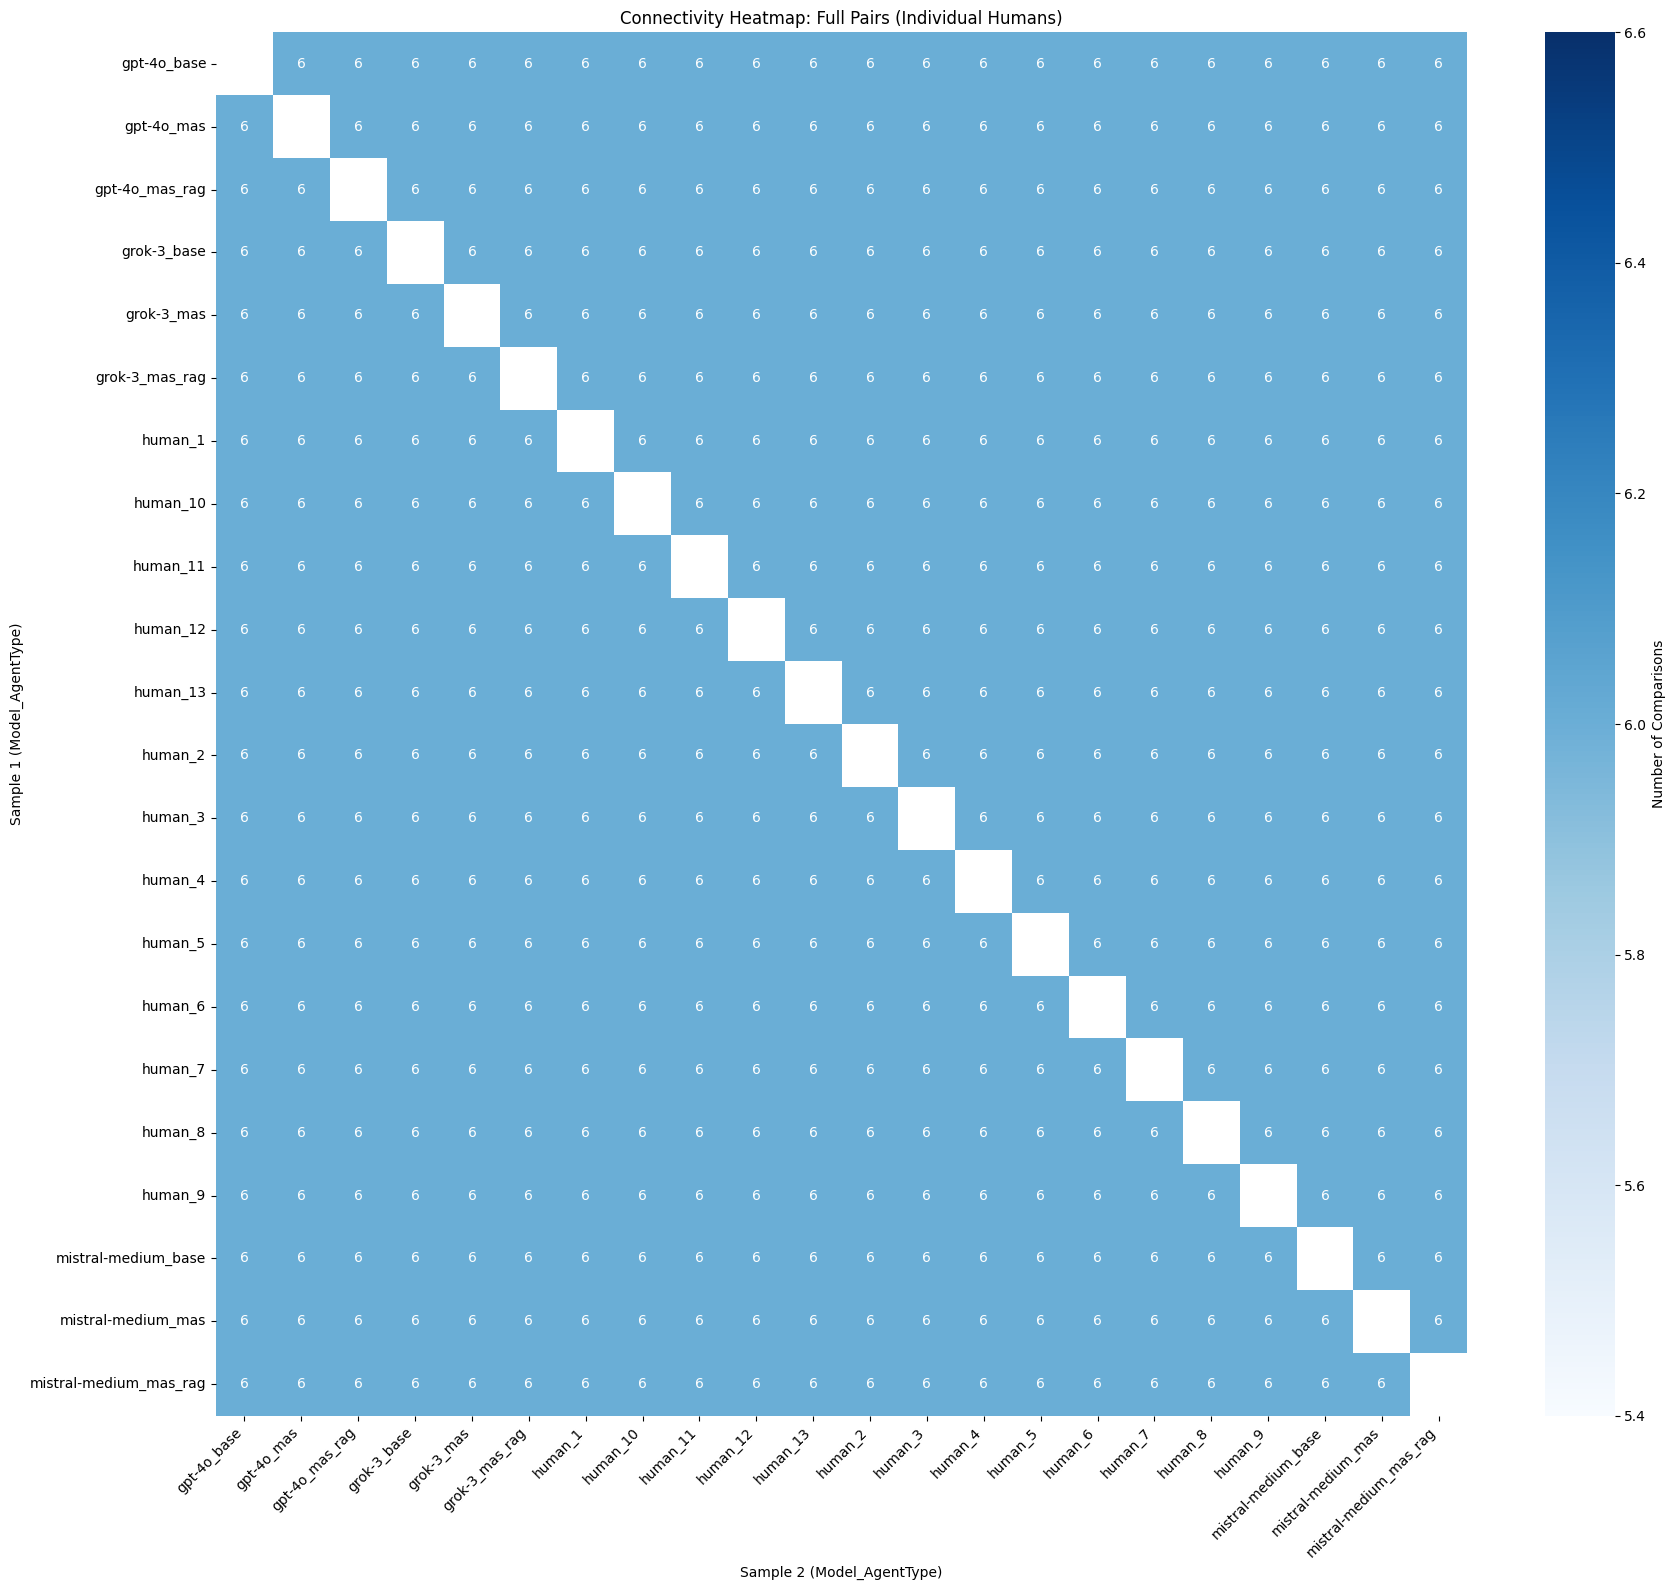

n = 22
n*ln(n) = 68.00
Unique off-diagonal pairs with at least one comparison: 231
Is unique_pairs > n*ln(n)? YES
Coefficient x: unique_pairs = x * n*ln(n) --> x = 3.40
Full Matrix
Comparisons included:
mas vs mas_rag vs base vs human_1 ... vs human_13

Number of comparisons in df: 1386
Total annotations needed (with 9 annotations per sample): 12474
Number of unique annotators needed (each does 3 annotations): 4158
Minutes per annotation (dialogue turns 4): 3.0
Total annotation time: 37422.0 mins (623.70 hours)
Time per annotator: 9.0 mins (0.15 hours)
Base cost (annotator payment): £5613.30
Platform fee (33%): £1852.39
Subtotal (before VAT): £7465.69
VAT on platform fee (20%): £370.48

TOTAL COST: £7836.17

Prolific Budget: £9550.19
Remaining budget: £1714.02
Within budget: True

Cost per comparison: £5.65
Max comparisons with budget: 1689


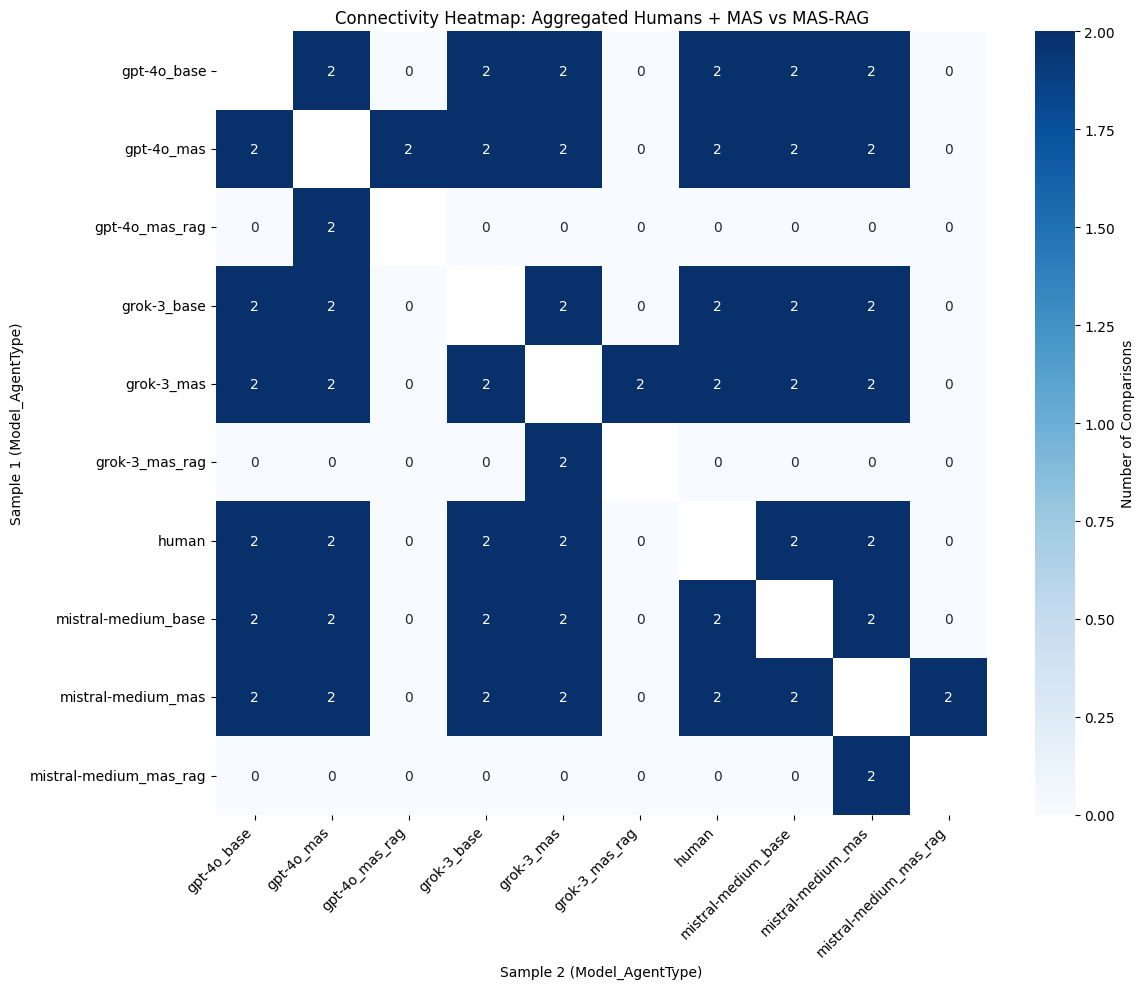

n = 10
n*ln(n) = 23.03
Unique off-diagonal pairs with at least one comparison: 24
Is unique_pairs > n*ln(n)? YES
Coefficient x: unique_pairs = x * n*ln(n) --> x = 1.04


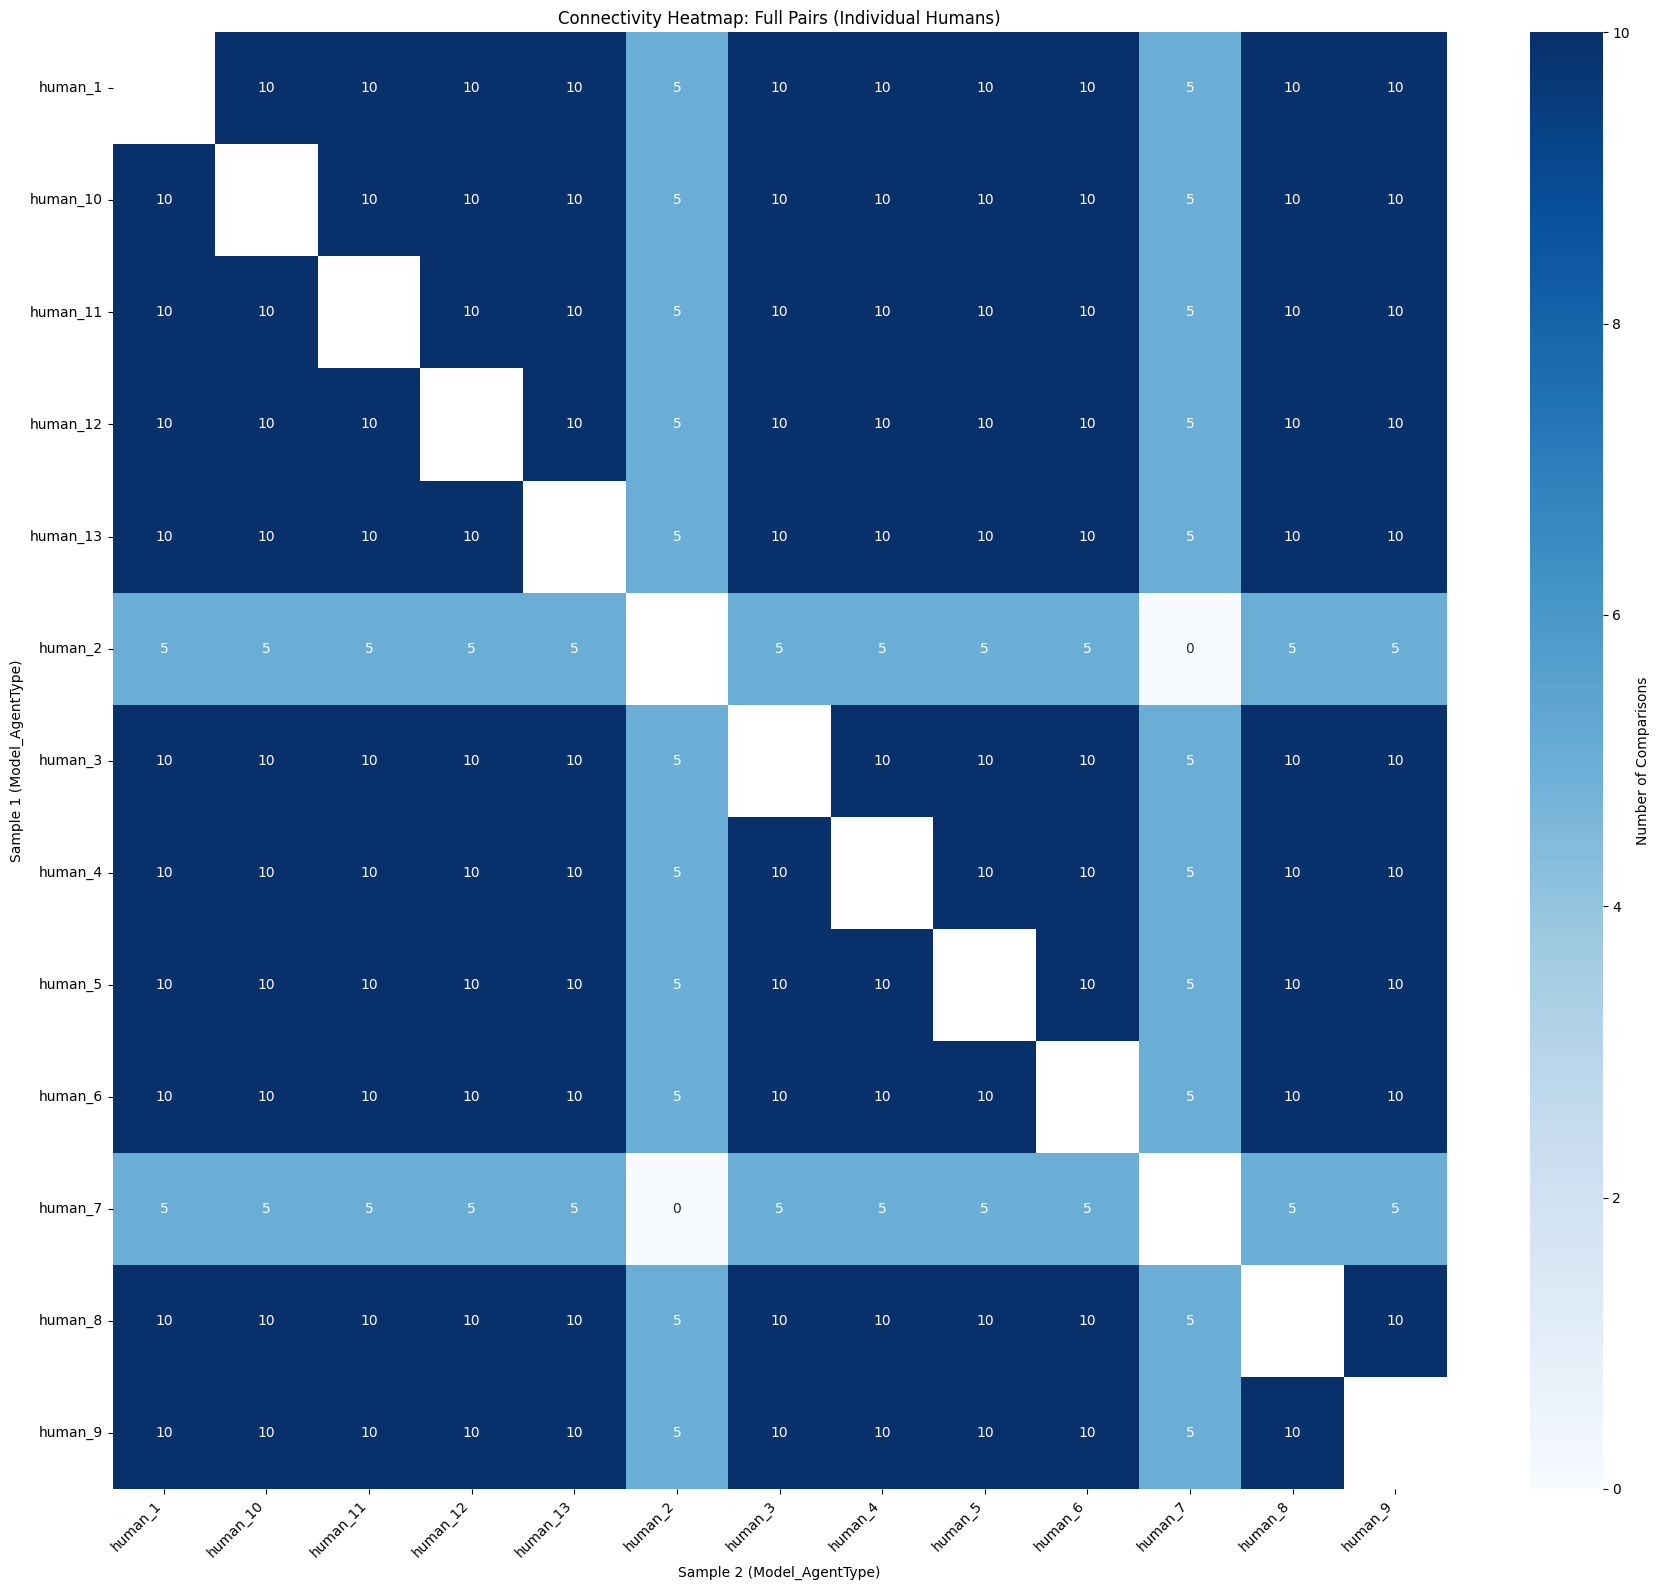

n = 13
n*ln(n) = 33.34
Unique off-diagonal pairs with at least one comparison: 77
Is unique_pairs > n*ln(n)? YES
Coefficient x: unique_pairs = x * n*ln(n) --> x = 2.31
Aggregate Matrix + H-H
Comparisons included:
mas vs mas_rag
mas vs base vs human, where humans are treated as one debater

individual humans, i.e. human_1, ... human_13
Number of comparisons in df: 852
Total annotations needed (with 9 annotations per sample): 7668
Number of unique annotators needed (each does 3 annotations): 2556
Minutes per annotation (dialogue turns 4): 3.0
Total annotation time: 23004.0 mins (383.40 hours)
Time per annotator: 9.0 mins (0.15 hours)
Base cost (annotator payment): £3450.60
Platform fee (33%): £1138.70
Subtotal (before VAT): £4589.30
VAT on platform fee (20%): £227.74

TOTAL COST: £4817.04

Prolific Budget: £9550.19
Remaining budget: £4733.15
Within budget: True

Cost per comparison: £5.65
Max comparisons with budget: 1689


{'num_comparisons': 852,
 'total_annotations': 7668,
 'num_annotators': 2556.0,
 'total_hours': 383.4,
 'base_cost': 3450.6,
 'platform_fee': 1138.698,
 'vat': 227.73960000000002,
 'total_cost': 4817.0376,
 'within_budget': True,
 'cost_per_comparison': 5.6537999999999995,
 'max_comparisons': 1689}

In [144]:
import seaborn as sns

HOURLY_RATE = 9
# TOTAL_ANNOTATIONS = 1000
NUM_ANNOTATIONS_PER_HUMAN = 3
NUM_ANNOTATIONS_PER_SAMPLE = 9
DIALOGUE_TURN_ANNOTATION_CHUNK_SIZE = 4 # So a chunk size of 2 would include one dialogue move from both speakers, chunk size = 4 would contain two dialogue moves from both speakers, and so on.
MINS_PER_CHUNK = 0.75
PLATFORM_FEE = 0.33
VAT = 0.2
PROLIFIC_BUDGET=9550.19

NUM_SAMPLES = 3
NUM_HUMAN_SAMPLES=5

chunked_df = chunk_debates(debates_df=all_df, num_dialogue_turns=DIALOGUE_TURN_ANNOTATION_CHUNK_SIZE)
mas_and_mas_rag_pairs_df = sample_mas_and_mas_rag_pairs(num_samples=NUM_SAMPLES)
processed_mas_and_mas_rag_pairs_df = process_mas_and_mas_rag_pairs(mas_and_mas_rag_pairs_df)

aggregate_pairs = sample_aggregate_pairs(df=chunked_df, num_samples=NUM_SAMPLES)
processed_aggregate_pairs_df = process_pairs(aggregate_pairs)

full_pairs = sample_full_pairs(df=chunked_df, num_samples=NUM_SAMPLES)
processed_full_pairs_df = process_pairs(full_pairs)

human_pairs = sample_human_pairs(chunked_df, NUM_HUMAN_SAMPLES)
processed_human_pairs_df = process_pairs(human_pairs)


# Helper functions
def extract_model(speaker_name):
    for model in ["gpt-4o", "mistral-medium", "grok-3"]:
        if model in speaker_name:
            return model
    return "human"

def extract_agent_type(speaker_name):
    if "mas_rag" in speaker_name:
        return "mas_rag"
    elif "mas" in speaker_name:
        return "mas"
    elif "base" in speaker_name:
        return "base"
    else:
        return "human"

def create_label(speaker_name, aggregate_humans: bool = True):
    model = extract_model(speaker_name)
    agent_type = extract_agent_type(speaker_name)
    if model == "human":
        if aggregate_humans:
            return "human"
        else:
            return speaker_name  # Keep individual human names like human_1, human_2, etc.
    return f"{model}_{agent_type}"

def plot_connectivity_heatmap(df, title, aggregate_humans: bool = True):
    df_copy = df.copy()

    df_copy["sample1_label"] = df_copy["sample1_speakerA"].apply(
        lambda x: create_label(x, aggregate_humans)
    )
    df_copy["sample2_label"] = df_copy["sample2_speakerA"].apply(
        lambda x: create_label(x, aggregate_humans)
    )
    
    # Get all unique labels and sort them for consistent ordering
    all_labels = sorted(set(df_copy["sample1_label"].unique()) | set(df_copy["sample2_label"].unique()))
    
    # Create crosstab with all labels
    comparison_matrix = pd.crosstab(
        df_copy["sample1_label"],
        df_copy["sample2_label"]
    )
    
    # Reindex to include all labels (fill missing with 0)
    comparison_matrix = comparison_matrix.reindex(index=all_labels, columns=all_labels, fill_value=0)


    # Make symmetric by adding transpose (since A vs B and B vs A are both valid comparisons)
    symmetric_matrix = comparison_matrix + comparison_matrix.T
    # Convert to float to allow np.nan
    symmetric_values = symmetric_matrix.values.astype(float)
    np.fill_diagonal(symmetric_values, np.nan)
    symmetric_matrix = pd.DataFrame(symmetric_values, index=all_labels, columns=all_labels)
    
    # Plot heatmap
    figsize = (12, 10) if aggregate_humans else (18, 16)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        symmetric_matrix,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        ax=ax,
        cbar_kws={"label": "Number of Comparisons"},
        mask=symmetric_matrix.isnull()  # Hide diagonal cells
    )
    plt.title(title)
    plt.xlabel("Sample 2 (Model_AgentType)")
    plt.ylabel("Sample 1 (Model_AgentType)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# =======================================================================================================================
#                                                       FULL MATRIX
# =======================================================================================================================

# Plot for full_w_mas_and_mas_rag_df (individual humans)
plot_connectivity_heatmap(
    processed_full_pairs_df, 
    "Connectivity Heatmap: Full Pairs (Individual Humans)",
    aggregate_humans=False
)

nlnn_connectivity_report(processed_full_pairs_df, aggregate_humans=False)
print("="*50)
print("Full Matrix")
print("="*50)
print("Comparisons included:")
# print("mas vs mas_rag")
print("mas vs mas_rag vs base vs human_1 ... vs human_13\n")
compute_cost(processed_full_pairs_df, 
             HOURLY_RATE, 
             NUM_ANNOTATIONS_PER_HUMAN, 
             NUM_ANNOTATIONS_PER_SAMPLE, 
             DIALOGUE_TURN_ANNOTATION_CHUNK_SIZE,
             MINS_PER_CHUNK,
             PLATFORM_FEE,
             VAT,
             PROLIFIC_BUDGET)


# =======================================================================================================================
#                                                       AGGREGATE MATRIX
# =======================================================================================================================

# Plot for aggregate_human_mas_and_mas_rag_pairs_df (aggregated humans)
plot_connectivity_heatmap(
    aggregate_human_mas_and_mas_rag_pairs_df, 
    "Connectivity Heatmap: Aggregated Humans + MAS vs MAS-RAG",
    aggregate_humans=True
)
nlnn_connectivity_report(aggregate_human_mas_and_mas_rag_pairs_df, aggregate_humans=True)

plot_connectivity_heatmap(
    processed_human_pairs_df, 
    "Connectivity Heatmap: Full Pairs (Individual Humans)",
    aggregate_humans=False
)
nlnn_connectivity_report(processed_human_pairs_df, aggregate_humans=False)
print("="*50)
print("Aggregate Matrix + H-H")
print("="*50)
print("Comparisons included:")
print("mas vs mas_rag")
print("mas vs base vs human, where humans are treated as one debater\n")
print("individual humans, i.e. human_1, ... human_13")
compute_cost(pd.concat([aggregate_human_mas_and_mas_rag_pairs_df,processed_human_pairs_df], ignore_index=True), 
             HOURLY_RATE, 
             NUM_ANNOTATIONS_PER_HUMAN, 
             NUM_ANNOTATIONS_PER_SAMPLE, 
             DIALOGUE_TURN_ANNOTATION_CHUNK_SIZE,
             MINS_PER_CHUNK,
             PLATFORM_FEE,
             VAT,
             PROLIFIC_BUDGET)



In [129]:
aggregate_human_mas_and_mas_rag_pairs_df

,pair_session_ids,comparison,sample1_speakerA,sample1_speakerB,sample1_dialogue_chunk,sample1_processed_dialogue_chunk,sample1_political_position,sample2_speakerA,sample2_speakerB,sample2_dialogue_chunk,sample2_processed_dialogue_chunk,sample2_political_position
0,"(gpt-4o_mas_rag:l__vs__grok-3_mas:r, gpt-4o_ma...","(gpt-4o_mas_rag, gpt-4o_mas)",gpt-4o_mas_rag,grok-3_mas,"[{'speaker': 'gpt-4o_mas_rag', 'timestamp': '2...",[{'Speaker A': 'Preventative care in universal...,left,gpt-4o_mas,mistral-medium_mas,"[{'speaker': 'gpt-4o_mas', 'timestamp': '2025-...",[{'Speaker A': 'Conditional welfare schemes ac...,left
1,"(gpt-4o_mas:r__vs__mistral-medium_mas:l, grok-...","(gpt-4o_mas, gpt-4o_mas_rag)",gpt-4o_mas,mistral-medium_mas,"[{'speaker': 'gpt-4o_mas', 'timestamp': '2025-...",[{'Speaker A': 'Government welfare schemes oft...,right,gpt-4o_mas_rag,grok-3_base,"[{'speaker': 'gpt-4o_mas_rag', 'timestamp': '2...","[{'Speaker A': 'Competition drives innovation,...",right
2,"(gpt-4o_base:r__vs__mistral-medium_mas_rag:l, ...","(mistral-medium_mas_rag, mistral-medium_mas)",mistral-medium_mas_rag,gpt-4o_base,"[{'speaker': 'mistral-medium_mas_rag', 'timest...",[{'Speaker A': 'Expansive welfare systems crea...,left,mistral-medium_mas,grok-3_mas,"[{'speaker': 'mistral-medium_mas', 'sentences_...",[{'Speaker A': 'Excessive welfare spending tra...,left
3,(mistral-medium_mas_rag:r__vs__mistral-medium_...,"(mistral-medium_mas_rag, mistral-medium_mas)",mistral-medium_mas_rag,mistral-medium_base,"[{'speaker': 'mistral-medium_base', 'timestamp...",[{'Speaker B': 'Publicly funded healthcare sys...,right,mistral-medium_mas,grok-3_mas,"[{'speaker': 'mistral-medium_mas', 'timestamp'...",[{'Speaker A': 'Why should we trust the govern...,right
4,"(grok-3_mas:l__vs__gpt-4o_mas:r, gpt-4o_base:r...","(grok-3_mas, grok-3_mas_rag)",grok-3_mas,gpt-4o_mas,"[{'speaker': 'grok-3_mas', 'timestamp': '2025-...",[{'Speaker A': 'Government-funded research is ...,left,grok-3_mas_rag,gpt-4o_base,"[{'speaker': 'grok-3_mas_rag', 'timestamp': '2...",[{'Speaker A': 'Government interference is ess...,left
...,...,...,...,...,...,...,...,...,...,...,...,...
187,"(KME13J, DL3D7S)","(human_9, human_7)",human_9,human_10,"[{'speaker': 'human_10', 'timestamp': '2026-01...",[{'Speaker B': 'So you agree that governments ...,right,human_7,gpt-4o_mas_rag,"[{'speaker': 'gpt-4o_mas_rag', 'timestamp': '2...",[{'Speaker B': 'The NHS in the UK continues to...,right
188,"(NEZTYI, XZV57F)","(human_12, human_9)",human_12,human_3,"[{'speaker': 'human_3', 'timestamp': '2026-01-...",[{'Speaker B': 'The government should crack do...,left,human_9,gpt-4o_base,"[{'speaker': 'human_9', 'timestamp': '2026-01-...",[{'Speaker A': 'How can those individuals get ...,left
189,"(KME13J, VIJPFB)","(human_9, human_12)",human_9,human_10,"[{'speaker': 'human_10', 'timestamp': '2026-01...",[{'Speaker B': 'So you agree that governments ...,right,human_12,human_5,"[{'speaker': 'human_5', 'timestamp': '2026-01-...",[{'Speaker B': 'The taxes should be as they ar...,right
190,"(NEZTYI, 1XHC4T)","(human_12, human_7)",human_12,human_3,"[{'speaker': 'human_3', 'timestamp': '2026-01-...",[{'Speaker B': 'The government should crack do...,left,human_7,human_12,"[{'speaker': 'human_12', 'timestamp': '2026-01...",[{'Speaker B': 'The government should allow pa...,left


In [130]:
processed_full_pairs_df

,pair_session_ids,comparison,sample1_speakerA,sample1_speakerB,sample1_dialogue_chunk,sample1_processed_dialogue_chunk,sample1_political_position,sample2_speakerA,sample2_speakerB,sample2_dialogue_chunk,sample2_processed_dialogue_chunk,sample2_political_position
0,"(gpt-4o_base:l__vs__mistral-medium_mas:r, grok...","(gpt-4o_base, grok-3_base)",gpt-4o_base,mistral-medium_mas,"[{'speaker': 'mistral-medium_mas', 'timestamp'...","[{'Speaker B': 'Charities, often funded by pri...",left,grok-3_base,gpt-4o_mas,"[{'speaker': 'grok-3_base', 'timestamp': '2025...",[{'Speaker A': 'I stand by my view that govern...,left
1,"(grok-3_mas_rag:r__vs__gpt-4o_base:l, grok-3_b...","(gpt-4o_base, grok-3_base)",gpt-4o_base,grok-3_mas_rag,"[{'speaker': 'grok-3_mas_rag', 'timestamp': '2...",[{'Speaker B': 'The NHS's vaccination success ...,left,grok-3_base,grok-3_mas,"[{'speaker': 'grok-3_base', 'timestamp': '2025...",[{'Speaker A': 'I stand by my view that strong...,left
2,"(gpt-4o_base:l__vs__mistral-medium_base:r, gro...","(gpt-4o_base, grok-3_base)",gpt-4o_base,mistral-medium_base,"[{'speaker': 'mistral-medium_base', 'timestamp...",[{'Speaker B': 'The NHS's size leads to ineffi...,left,grok-3_base,gpt-4o_base,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",[{'Speaker B': 'Regulation and subsidies can s...,left
3,"(grok-3_mas_rag:l__vs__gpt-4o_base:r, grok-3_b...","(gpt-4o_base, grok-3_base)",gpt-4o_base,grok-3_mas_rag,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",[{'Speaker A': 'A fully public system under st...,right,grok-3_base,grok-3_mas,"[{'speaker': 'grok-3_mas', 'timestamp': '2025-...",[{'Speaker B': 'How can you justify scaling ba...,right
4,"(grok-3_mas_rag:l__vs__gpt-4o_base:r, grok-3_m...","(gpt-4o_base, grok-3_base)",gpt-4o_base,grok-3_mas_rag,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",[{'Speaker A': 'Targeted reforms and increased...,right,grok-3_base,grok-3_mas_rag,"[{'speaker': 'grok-3_mas_rag', 'timestamp': '2...",[{'Speaker B': 'State intervention is the only...,right
...,...,...,...,...,...,...,...,...,...,...,...,...
1381,"(16UHBX, 1XHC4T)","(human_12, human_7)",human_12,grok-3_mas,"[{'speaker': 'grok-3_mas', 'timestamp': '2026-...","[{'Speaker B': 'Every day in school, regardles...",left,human_7,human_12,"[{'speaker': 'human_7', 'timestamp': '2026-01-...",[{'Speaker A': 'One of the greatest markers of...,left
1382,"(16UHBX, 1XHC4T)","(human_12, human_7)",human_12,grok-3_mas,"[{'speaker': 'human_12', 'timestamp': '2026-01...",[{'Speaker A': 'In the final few weeks of scho...,left,human_7,human_12,"[{'speaker': 'human_12', 'timestamp': '2026-01...","[{'Speaker B': 'Education is highly important,...",left
1383,"(DL3D7S, VIJPFB)","(human_7, human_12)",human_7,gpt-4o_mas_rag,"[{'speaker': 'gpt-4o_mas_rag', 'timestamp': '2...",[{'Speaker B': 'The NHS in the UK continues to...,right,human_12,human_5,"[{'speaker': 'human_5', 'timestamp': '2026-01-...",[{'Speaker B': 'The taxes should be as they ar...,right
1384,"(SQFGVX, VIJPFB)","(human_7, human_12)",human_7,gpt-4o_base,"[{'speaker': 'human_7', 'timestamp': '2026-01-...",[{'Speaker A': 'I disagree. The biggest govern...,right,human_12,human_5,"[{'speaker': 'human_12', 'timestamp': '2026-01...",[{'Speaker A': 'Are taxes the only way to deve...,right


In [131]:
import ftfy
fixed = ftfy.fix_text("CafÃ©")
print(fixed)

Café


In [132]:
def safe_fix_mojibake(text):
    """Safely fix mojibake only if needed"""
    if not isinstance(text, str):
        return text
    
    try:
        # Try to encode as latin-1 and decode as utf-8
        fixed = text.encode('latin-1').decode('utf-8')
        return ftfy.fix_text(fixed)
    except (UnicodeEncodeError, UnicodeDecodeError):
        # If it fails, the text is likely already correct
        # Just apply ftfy in case there are other issues
        return ftfy.fix_text(text)

In [133]:
# final_csv_list = []

# for i, row in aggregate_human_mas_and_mas_rag_pairs_df.iterrows():
#     d = {
#         # "META_ComparisonID" : i,
#         "META_pair_session_ids" : row["pair_session_ids"],
#         "META_comparison" : row["comparison"],
#         "META_sample1_speakerA" : row["sample1_speakerA"],
#         "META_sample1_speakerB" : row["sample1_speakerB"],
#         "META_sample1_dialogue_chunk" : row["sample1_dialogue_chunk"],
#         "META_sample1_political_position" : row["sample1_political_position"],
#         "META_sample1_political_position" : row["sample2_political_position"],

#         "Debate Topic" : "Debate the trade-offs of government intervention across a range of issues, including healthcare, immigration, and welfare.",

#         # "Debate 1" : "\n\n".join([f'{k}: "{ftfy.fix_text(v.encode('latin-1').decode('utf-8'))}"' for turn in row["sample1_processed_dialogue_chunk"] for k, v in turn.items()]),
#         # "Debate 2" : "\n\n".join([f'{k}: "{ftfy.fix_text(v.encode('latin-1').decode('utf-8'))}"' for turn in row["sample2_processed_dialogue_chunk"] for k, v in turn.items()])
#         "Debate 1": "\n\n".join([f'{k}: "{safe_fix_mojibake(v)}"' 
#                                   for turn in row["sample1_processed_dialogue_chunk"] 
#                                   for k, v in turn.items()]),
#         "Debate 2": "\n\n".join([f'{k}: "{safe_fix_mojibake(v)}"' 
#                                   for turn in row["sample2_processed_dialogue_chunk"] 
#                                   for k, v in turn.items()])
#     }
#     final_csv_list.append(d)



# final_df = pd.DataFrame(final_csv_list)

In [134]:
# final_df.to_csv("data/aggregate-most-persuasive-dataset-with-samples-for-prolific.csv", index_label="META_ComparisonID")

In [138]:
final_csv_list = []

for i, row in processed_full_pairs_df.iterrows():
    d = {
        # "META_ComparisonID" : i,
        "META_pair_session_ids" : row["pair_session_ids"],
        "META_comparison" : row["comparison"],
        "META_sample1_speakerA" : row["sample1_speakerA"],
        "META_sample1_speakerB" : row["sample1_speakerB"],
        "META_sample1_dialogue_chunk" : row["sample1_dialogue_chunk"],
        "META_sample1_political_position" : row["sample1_political_position"],
        "META_sample2_political_position" : row["sample2_political_position"],

        "Debate Topic" : "Debate the trade-offs of government intervention across a range of issues, including healthcare, immigration, and welfare.",

        # "Debate 1" : "\n\n".join([f'{k}: "{ftfy.fix_text(v.encode('latin-1').decode('utf-8'))}"' for turn in row["sample1_processed_dialogue_chunk"] for k, v in turn.items()]),
        # "Debate 2" : "\n\n".join([f'{k}: "{ftfy.fix_text(v.encode('latin-1').decode('utf-8'))}"' for turn in row["sample2_processed_dialogue_chunk"] for k, v in turn.items()])
        "Debate 1": "\n\n".join([f'{k}: "{safe_fix_mojibake(v)}"' 
                                  for turn in row["sample1_processed_dialogue_chunk"] 
                                  for k, v in turn.items()]),
        "Debate 2": "\n\n".join([f'{k}: "{safe_fix_mojibake(v)}"' 
                                  for turn in row["sample2_processed_dialogue_chunk"] 
                                  for k, v in turn.items()])
    }
    final_csv_list.append(d)


final_df = pd.DataFrame(final_csv_list)

In [140]:
final_df.to_csv("data/full-most-persuasive-dataset-with-samples-for-prolific.csv", index_label="META_ComparisonID", encoding="utf-8")